
===================== casa1PM =====================
Rodando casa1PM - MP1
Rodando casa1PM - MP2.5
Rodando casa1PM - MP10

===================== casa2PM =====================
Rodando casa2PM - MP1
Rodando casa2PM - MP2.5
Rodando casa2PM - MP10

===================== casa3PM =====================
Rodando casa3PM - MP1
Rodando casa3PM - MP2.5
Rodando casa3PM - MP10

===================== casa4PM =====================
Rodando casa4PM - MP1
Rodando casa4PM - MP2.5
Rodando casa4PM - MP10


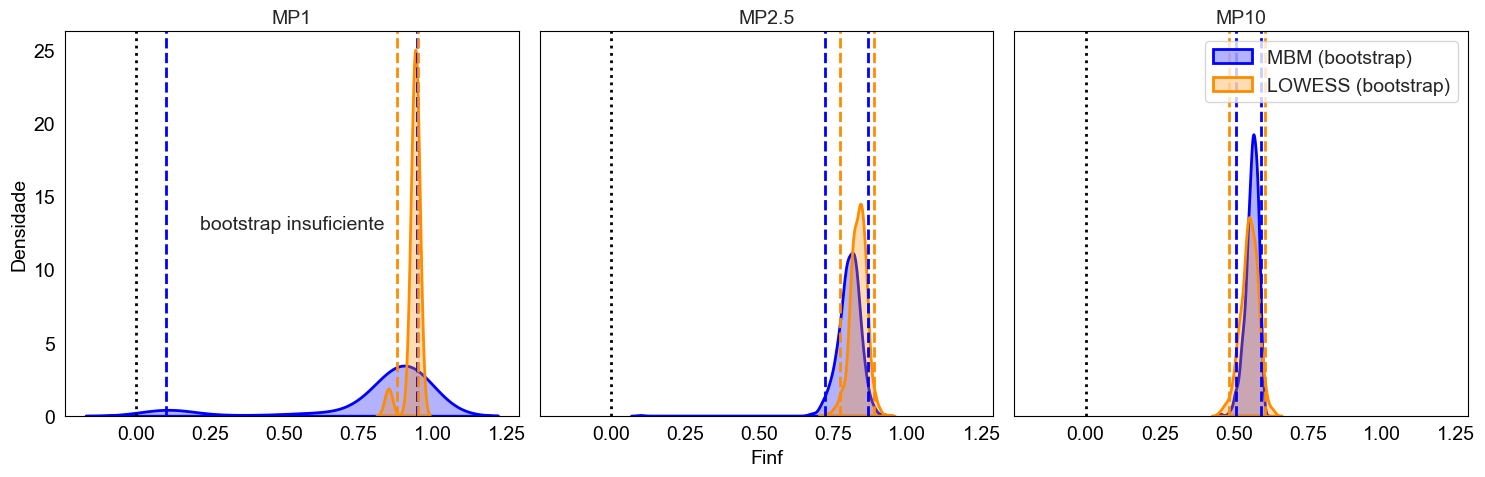

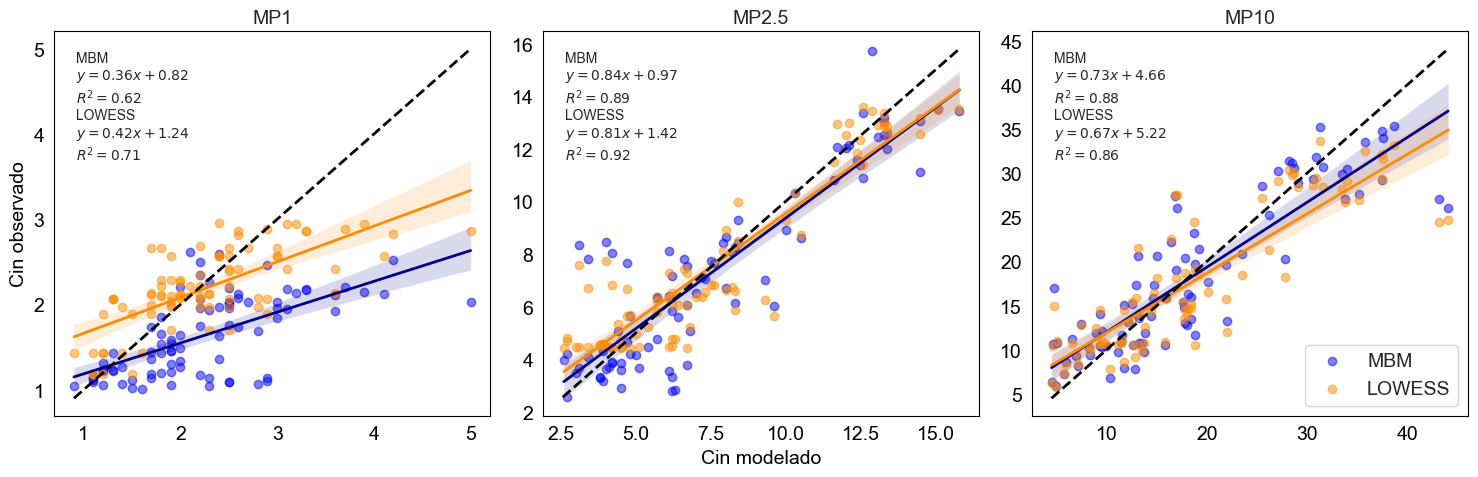

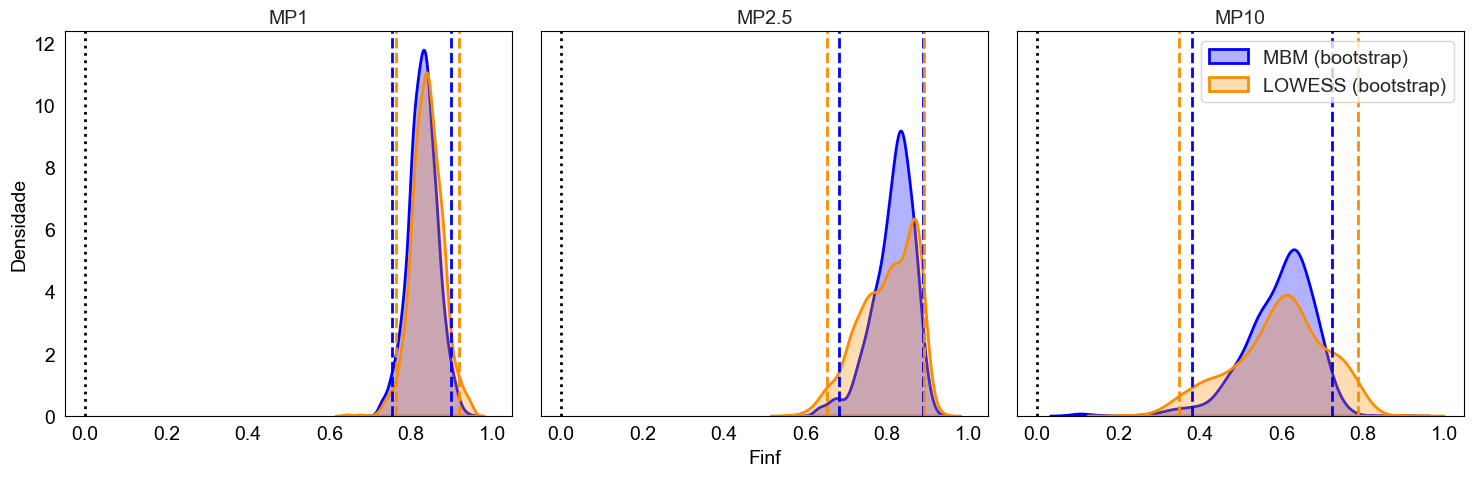

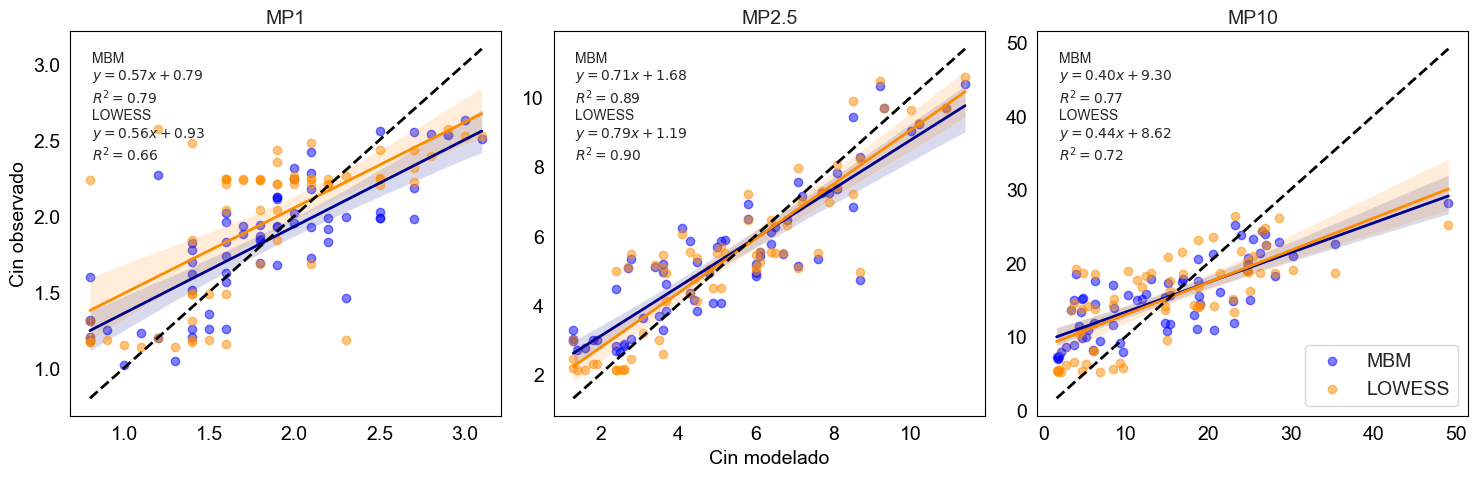

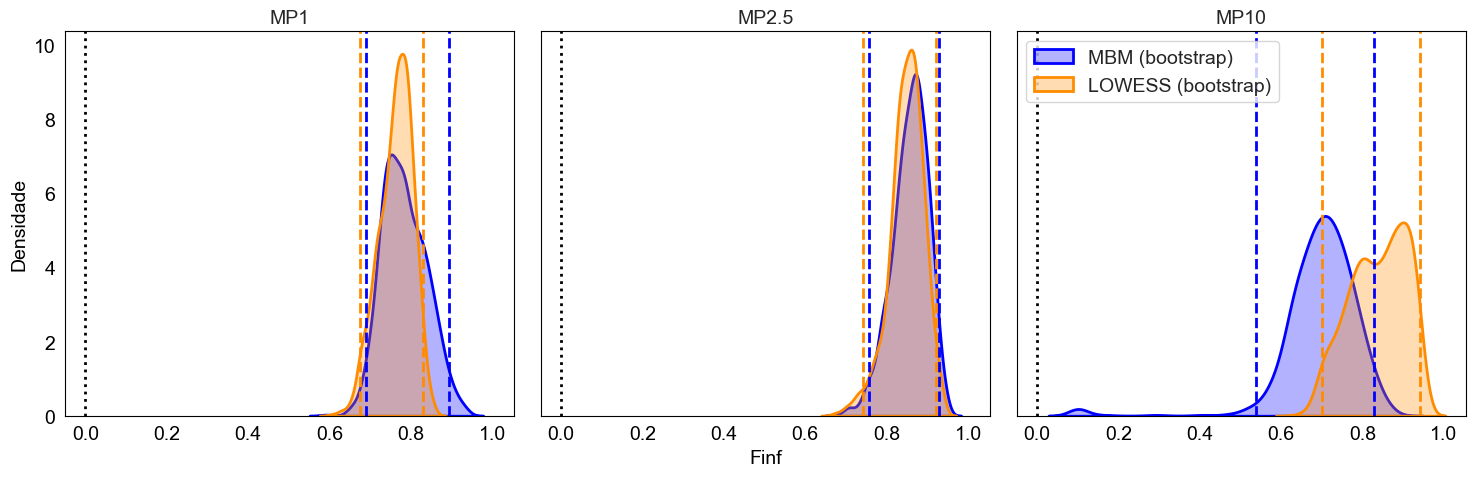

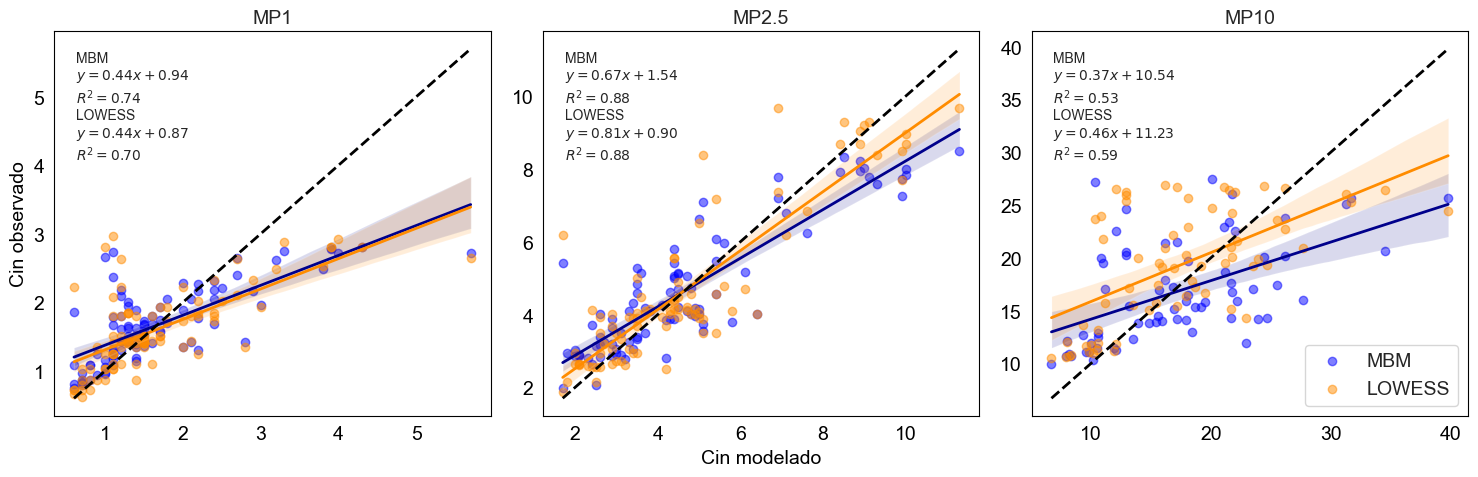

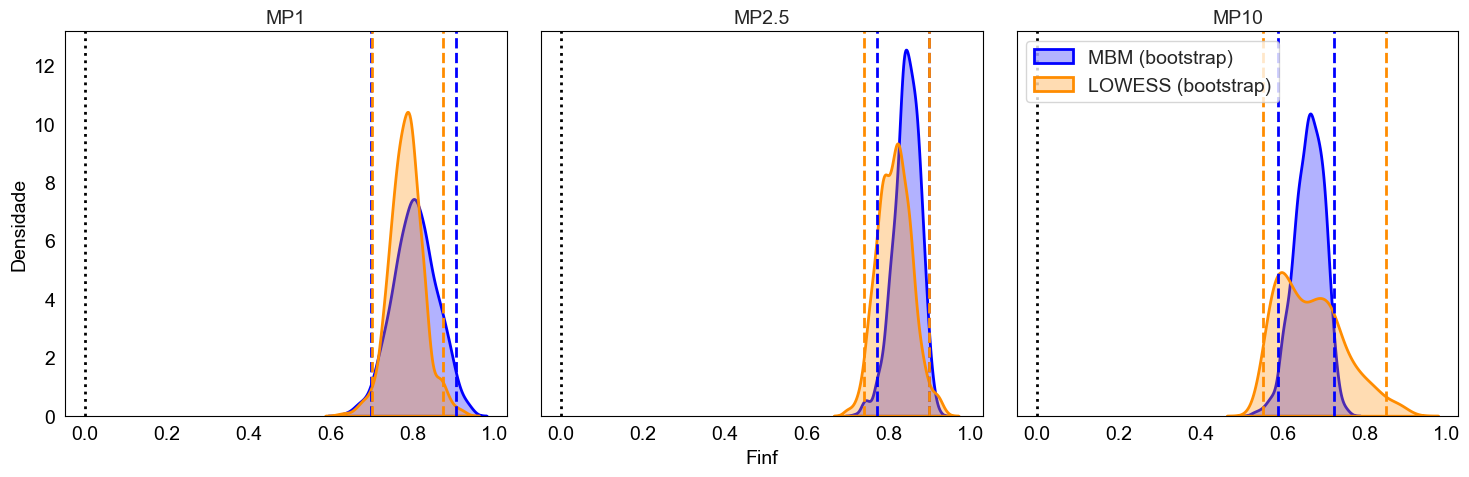

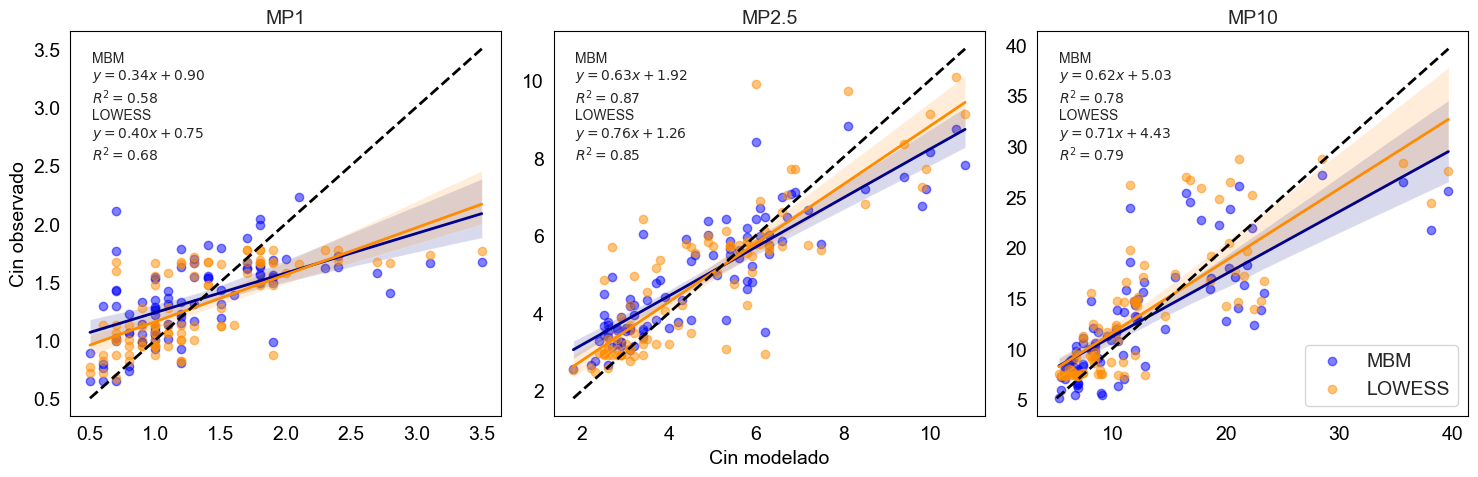


Pipeline concluído com sucesso.
Resultados salvos em: C:\Users\melin\OneDrive\Área de Trabalho\projetosVScode\saida_pipeline_lote


,casa,fracao,origem_ajuste_MBM,n_total,n_externo_fit,Finf_hat,k_hat,Finf_mediana_boot,Finf_IC95_inf,Finf_IC95_sup,...,RMSE_MBM,MAE_MBM,R2_MBM,MBE_MBM,NRMSE_MBM,RMSE_LOWESS,MAE_LOWESS,R2_LOWESS,MBE_LOWESS,NRMSE_LOWESS
0,casa1PM,MP1,blocos_externos,90,86,0.999000,0.111357,0.901868,0.100000,0.947945,...,1.283811,0.787297,-0.200852,-0.742821,0.538662,1.026426,0.543688,0.232385,-0.188798,0.430668
1,casa1PM,MP2.5,blocos_externos,90,83,0.810494,0.955678,0.805859,0.721136,0.868810,...,3.331691,1.744296,0.510814,-0.842318,0.407685,3.199444,1.586095,0.548879,-0.598678,0.391502
2,casa1PM,MP10,blocos_externos,90,85,0.572356,0.791215,0.563003,0.507111,0.593347,...,7.460037,4.658112,0.588919,-1.398155,0.380593,7.909015,4.919663,0.537948,-2.015983,0.403498
3,casa2PM,MP1,blocos_externos,71,65,0.830531,0.637194,0.828270,0.752357,0.896557,...,2.305867,0.751345,0.017211,-0.486759,1.003780,2.274499,0.814492,0.043768,-0.350947,0.990125
4,casa2PM,MP2.5,blocos_externos,71,66,0.811882,1.091910,0.823108,0.682084,0.888547,...,3.148653,1.487312,0.239615,-0.467491,0.543267,3.136324,1.451018,0.245558,-0.511660,0.541140
5,casa2PM,MP10,blocos_externos,71,67,0.579553,0.905832,0.610393,0.380573,0.723155,...,7.478085,5.968622,0.446759,-0.271183,0.483116,7.819416,6.177590,0.395102,-0.595604,0.505167
6,casa3PM,MP1,blocos_externos,96,95,0.733410,0.209099,0.779203,0.689023,0.894823,...,0.635930,0.410859,0.523751,-0.004493,0.378717,0.666433,0.429484,0.476968,-0.061307,0.396883
7,casa3PM,MP2.5,blocos_externos,96,89,0.875581,0.861730,0.862036,0.756370,0.929501,...,1.339974,0.977930,0.736296,-0.180869,0.265780,1.286093,0.904884,0.757077,-0.129733,0.255093
8,casa3PM,MP10,blocos_externos,96,68,0.709891,1.166489,0.706277,0.537646,0.828463,...,10.926868,7.780925,0.110845,-4.892477,0.491671,10.015600,7.180920,0.252966,-2.576106,0.450667
9,casa4PM,MP1,blocos_externos,95,91,0.795528,0.717344,0.803520,0.698713,0.904871,...,0.695791,0.402603,0.227902,-0.059147,0.495132,0.686035,0.381002,0.249402,-0.120760,0.488190


,casa,fracao,delta_Finf_MBM_menos_LOWESS_mediana,delta_Finf_IC95_inf,delta_Finf_IC95_sup
0,casa1PM,MP1,0.000000,-0.117900,0.021718
1,casa1PM,MP2.5,0.031566,-0.082028,0.124568
2,casa1PM,MP10,0.037399,-0.030761,0.090831
3,casa2PM,MP1,0.133647,-0.026820,0.230225
4,casa2PM,MP2.5,0.099326,-0.010979,0.302170
5,casa2PM,MP10,0.028552,-0.082359,0.205405
6,casa3PM,MP1,0.020811,-0.049693,0.095254
7,casa3PM,MP2.5,0.042752,-0.013419,0.113960
8,casa3PM,MP10,0.024633,-0.124733,0.126697
9,casa4PM,MP1,0.068635,0.002316,0.153597


,casa,fracao,parametro,modelo,valor
0,casa1PM,MP1,Finf,MBM,0.946997
1,casa1PM,MP1,Finf,MBM,0.886682
2,casa1PM,MP1,Finf,MBM,0.946968
3,casa1PM,MP1,Finf,MBM,0.940552
4,casa1PM,MP1,Finf,MBM,0.868494
...,...,...,...,...,...
33929,casa4PM,MP10,Finf_proxy,LOWESS,0.565372
33930,casa4PM,MP10,Finf_proxy,LOWESS,0.594958
33931,casa4PM,MP10,Finf_proxy,LOWESS,0.712732
33932,casa4PM,MP10,Finf_proxy,LOWESS,0.639081


In [12]:
# ============================================================
# PIPELINE EM LOTE: MBM + LOWESS + IC95% + DM + TAYLOR + RESÍDUOS
# + PAINEL BOOTSTRAP + RIDGE PLOT
# ============================================================

import os
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.optimize import minimize
from scipy.stats import t as t_dist

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from statsmodels.nonparametric.smoothers_lowess import lowess

# ============================================================
# 1) PARÂMETROS GLOBAIS
# ============================================================

filepaths = [
    r"C:\Users\melin\OneDrive\Área de Trabalho\projetosVScode\casa1PM.xlsx",
    r"C:\Users\melin\OneDrive\Área de Trabalho\projetosVScode\casa2PM.xlsx",
    r"C:\Users\melin\OneDrive\Área de Trabalho\projetosVScode\casa3PM.xlsx",
    r"C:\Users\melin\OneDrive\Área de Trabalho\projetosVScode\casa4PM.xlsx",
]

OUTDIR = Path("saida_pipeline_lote")
OUTDIR.mkdir(exist_ok=True)

FIGDIR = OUTDIR / "figuras"
FIGDIR.mkdir(exist_ok=True)

N_BOOT = 1000
BLOCK_SIZE = 12
LOWESS_FRAC = 0.3
MIN_BLOCK_LEN = 4
ALPHA = 0.05
MIN_BOOT_SAMPLES = 30

# Padronização: usar sempre MP1, MP2.5 e MP10
FRACOES = {
    "MP1":   [("cinPM1", "coutPM1")],
    "MP2.5": [("cinPM25", "coutPM25"), ("cinPM2.5", "coutPM2.5")],
    "MP10":  [("cinPM10", "coutPM10")]
}

# Estilo dos gráficos
sns.set_style("white")
plt.rcParams.update({
    "font.size": 14,
    "axes.edgecolor": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    #"xtick.size": 12,
    "xtick.direction": "out",
    "ytick.direction": "out",
    #"ytick.size": 12,
    "ytick.color": "black",
    "axes.titlesize": 14,
    "axes.labelsize": 14,
    "legend.fontsize": 14
})

# ============================================================
# 2) FUNÇÕES AUXILIARES
# ============================================================

def get_cols(df, frac_key):
    """
    Resolve automaticamente os nomes das colunas da fração.
    """
    candidatos = FRACOES[frac_key]
    for cin_col, cout_col in candidatos:
        if cin_col in df.columns and cout_col in df.columns:
            return cin_col, cout_col
    raise KeyError(
        f"Colunas não encontradas para {frac_key}. "
        f"Colunas disponíveis: {list(df.columns)}"
    )


def clean_array(x):
    x = np.asarray(x, float)
    return x[np.isfinite(x)]


def limpar_bootstrap(x, min_samples=MIN_BOOT_SAMPLES):
    x = clean_array(x)
    if len(x) < min_samples:
        return np.array([])
    return x


def rmse(y_true, y_pred):
    m = np.isfinite(y_true) & np.isfinite(y_pred)
    if m.sum() == 0:
        return np.nan
    return np.sqrt(mean_squared_error(y_true[m], y_pred[m]))


def mae(y_true, y_pred):
    m = np.isfinite(y_true) & np.isfinite(y_pred)
    if m.sum() == 0:
        return np.nan
    return mean_absolute_error(y_true[m], y_pred[m])


def r2(y_true, y_pred):
    m = np.isfinite(y_true) & np.isfinite(y_pred)
    if m.sum() < 2:
        return np.nan
    return r2_score(y_true[m], y_pred[m])


def mbe(y_true, y_pred):
    m = np.isfinite(y_true) & np.isfinite(y_pred)
    if m.sum() == 0:
        return np.nan
    return np.mean(y_pred[m] - y_true[m])


def nrmse_mean_obs(y_true, y_pred):
    m = np.isfinite(y_true) & np.isfinite(y_pred)
    if m.sum() == 0:
        return np.nan
    mean_obs = np.mean(y_true[m])
    if np.isclose(mean_obs, 0):
        return np.nan
    return rmse(y_true[m], y_pred[m]) / mean_obs


def calc_metrics(y_true, y_pred):
    return {
        "RMSE": rmse(y_true, y_pred),
        "MAE": mae(y_true, y_pred),
        "R2": r2(y_true, y_pred),
        "MBE": mbe(y_true, y_pred),
        "NRMSE_obs_mean": nrmse_mean_obs(y_true, y_pred)
    }


def ci_percentile(x, alpha=0.05):
    x = clean_array(x)
    if len(x) == 0:
        return np.nan, np.nan, np.nan
    med = np.median(x)
    lo = np.percentile(x, 100 * (alpha / 2))
    hi = np.percentile(x, 100 * (1 - alpha / 2))
    return med, lo, hi


def moving_block_indices(n, block_size):
    idx = []
    if n <= 0:
        return np.array([], dtype=int)

    bs = int(max(1, min(block_size, n)))

    while len(idx) < n:
        start = np.random.randint(0, n - bs + 1)
        idx.extend(range(start, start + bs))

    return np.array(idx[:n], dtype=int)


# ============================================================
# 3) OUTLIERS EM COUT
# ============================================================

def substituir_outliers_media_local(x, window=3):
    x = np.asarray(x, float).copy()

    if len(x) == 0:
        return x

    q1 = np.nanpercentile(x, 25)
    q3 = np.nanpercentile(x, 75)
    iqr = q3 - q1

    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr

    out = (x < lim_inf) | (x > lim_sup)

    for i in np.where(out)[0]:
        i0 = max(0, i - window)
        i1 = min(len(x), i + window + 1)
        viz = x[i0:i1]
        viz = viz[(viz >= lim_inf) & (viz <= lim_sup)]
        if len(viz) > 0:
            x[i] = np.nanmean(viz)

    return x


# ============================================================
# 4) CENSURA
# ============================================================

def classificar_origem(Cin, Cout, Cin_lag, Cout_lag, ratio_th, diff_in, diff_ext):
    eps = 1e-6

    ratio = Cin / (Cout + eps)
    dCin = Cin - Cin_lag
    dCout = Cout - Cout_lag

    if (ratio > ratio_th) and (dCin > diff_in):
        return "interno"

    if ((ratio <= ratio_th) or (abs(Cin - Cout) <= diff_ext) and (abs(dCin - dCout) <= diff_ext)):
        return "externo"

    return "desconhecido"


def aplicar_censura(Cin, Cout, frac_key):
    if frac_key == "MP1":
        ratio_th, diff_in, diff_ext = 1.2, 2.0, 3
    elif frac_key == "MP2.5":
        ratio_th, diff_in, diff_ext = 1.2, 3.0, 5
    else:  # MP10
        ratio_th, diff_in, diff_ext = 1.2, 5.0, 7

    labels = ["desconhecido"]
    for t in range(1, len(Cin)):
        labels.append(
            classificar_origem(
                Cin[t], Cout[t], Cin[t-1], Cout[t-1],
                ratio_th=ratio_th,
                diff_in=diff_in,
                diff_ext=diff_ext
            )
        )
    return np.array(labels)


def gerar_blocos_externos(labels, min_len=4):
    blocos = []
    start = None

    for i, lab in enumerate(labels):
        if lab == "externo":
            if start is None:
                start = i
        else:
            if start is not None and i - start >= min_len:
                blocos.append(np.arange(start, i))
            start = None

    if start is not None and len(labels) - start >= min_len:
        blocos.append(np.arange(start, len(labels)))

    return blocos


def concat_blocos(Cin, Cout, blocos):
    if len(blocos) == 0:
        return np.array([]), np.array([]), np.array([], dtype=int)
    idx = np.concatenate(blocos)
    return Cin[idx], Cout[idx], idx


# ============================================================
# 5) MODELO MBM
# ============================================================

def simular_mbm(Cin_init, Cout, Finf, k):
    Cout = np.asarray(Cout, float)
    n = len(Cout)

    if n == 0 or not np.isfinite(Cin_init) or not np.isfinite(Finf) or not np.isfinite(k):
        return np.full(n, np.nan)

    pred = np.zeros(n, dtype=float)
    pred[0] = Cin_init

    for t in range(1, n):
        pred[t] = Finf * Cout[t] + (pred[t-1] - Finf * Cout[t]) * np.exp(-k)

    return pred


def ajustar_mbm(Cin, Cout):
    Cin = np.asarray(Cin, float)
    Cout = np.asarray(Cout, float)

    mask = np.isfinite(Cin) & np.isfinite(Cout)
    Cin = Cin[mask]
    Cout = Cout[mask]

    if len(Cin) < 5:
        return np.nan, np.nan, np.full(len(Cin), np.nan)

    def obj(par):
        Finf, k = par
        pred = simular_mbm(Cin[0], Cout, Finf, k)
        if np.all(~np.isfinite(pred)):
            return np.inf
        return np.mean((Cin - pred) ** 2)

    res = minimize(
        obj,
        x0=np.array([0.7, 0.5]),
        bounds=[(0.1, 0.999), (1e-6, 5.0)],
        method="L-BFGS-B"
    )

    if not res.success:
        return np.nan, np.nan, np.full(len(Cin), np.nan)

    Finf_hat, k_hat = res.x
    pred = simular_mbm(Cin[0], Cout, Finf_hat, k_hat)
    return Finf_hat, k_hat, pred


# ============================================================
# 6) LOWESS
# ============================================================

def ajustar_lowess(Cin, Cout, frac=0.25):
    Cin = np.asarray(Cin, float)
    Cout = np.asarray(Cout, float)

    mask = np.isfinite(Cin) & np.isfinite(Cout)
    y = np.full(len(Cin), np.nan)

    if mask.sum() < 5:
        return y

    try:
        y[mask] = lowess(
            endog=Cin[mask],
            exog=Cout[mask],
            frac=frac,
            return_sorted=False
        )
    except Exception:
        return y

    return y


# ============================================================
# 7) BOOTSTRAP MBM
# ============================================================

def bootstrap_mbm(Cin, Cout, n_boot=1000, block_size=12):
    Cin = np.asarray(Cin, float)
    Cout = np.asarray(Cout, float)

    mask = np.isfinite(Cin) & np.isfinite(Cout)
    Cin = Cin[mask]
    Cout = Cout[mask]

    n = len(Cin)
    if n < 5:
        return np.array([]), np.array([]), np.empty((0, n))

    Finf_vals = []
    k_vals = []
    preds = []

    for _ in range(n_boot):
        idx = moving_block_indices(n, block_size)
        Cin_b = Cin[idx]
        Cout_b = Cout[idx]

        try:
            Finf_b, k_b, _ = ajustar_mbm(Cin_b, Cout_b)
            if not np.isfinite(Finf_b) or not np.isfinite(k_b):
                continue

            pred_full = simular_mbm(Cin[0], Cout, Finf_b, k_b)
            if np.all(~np.isfinite(pred_full)):
                continue

            Finf_vals.append(Finf_b)
            k_vals.append(k_b)
            preds.append(pred_full)

        except Exception:
            continue

    if len(Finf_vals) == 0:
        return np.array([]), np.array([]), np.empty((0, n))

    return np.asarray(Finf_vals), np.asarray(k_vals), np.asarray(preds)


# ============================================================
# 8) BOOTSTRAP LOWESS
# ============================================================

def finf_lowess_proxy(Cout, Cin_pred):
    Cout = np.asarray(Cout, float)
    Cin_pred = np.asarray(Cin_pred, float)

    m = np.isfinite(Cout) & np.isfinite(Cin_pred) & (Cout > 1e-8)
    if m.sum() < 5:
        return np.nan

    ratio = Cin_pred[m] / Cout[m]
    ratio = ratio[np.isfinite(ratio)]
    ratio = np.clip(ratio, 0.1, 0.999)
    if len(ratio) == 0:
        return np.nan

    return np.median(ratio)


def bootstrap_lowess(Cin, Cout, frac=0.25, n_boot=1000, block_size=12):
    Cin = np.asarray(Cin, float)
    Cout = np.asarray(Cout, float)

    mask = np.isfinite(Cin) & np.isfinite(Cout)
    Cin2 = Cin[mask]
    Cout2 = Cout[mask]
    n = len(Cin2)

    if n < 5:
        return np.empty((0, len(Cin))), np.full(len(Cin), np.nan)

    pred_ref = ajustar_lowess(Cin, Cout, frac=frac)

    preds = []
    bs = int(max(1, min(block_size, n)))

    for _ in range(n_boot):
        idx = moving_block_indices(n, bs)
        Cin_b = Cin2[idx]
        Cout_b = Cout2[idx]

        try:
            # Ajusta LOWESS no bootstrap reamostrado
            # e depois projeta na série original por interpolação
            pred_b_sorted = lowess(
                endog=Cin_b,
                exog=Cout_b,
                frac=frac,
                return_sorted=True
            )

            x_boot = pred_b_sorted[:, 0]
            y_boot = pred_b_sorted[:, 1]

            order = np.argsort(x_boot)
            x_boot = x_boot[order]
            y_boot = y_boot[order]

            x_unique, idx_unique = np.unique(x_boot, return_index=True)
            y_unique = y_boot[idx_unique]

            if len(x_unique) < 2:
                continue

            pred_full = np.full(len(Cin), np.nan)
            valid_full = np.isfinite(Cout)
            pred_full[valid_full] = np.interp(
                Cout[valid_full],
                x_unique,
                y_unique,
                left=y_unique[0],
                right=y_unique[-1]
            )

            preds.append(pred_full)

        except Exception:
            continue

    if len(preds) == 0:
        return np.empty((0, len(Cin))), pred_ref

    return np.asarray(preds), pred_ref


# ============================================================
# 9) DIFERENÇA DE Finf ENTRE MODELOS
# ============================================================

def bootstrap_diff_finf(Cin, Cout, frac=0.25, n_boot=1000, block_size=12):
    Cin = np.asarray(Cin, float)
    Cout = np.asarray(Cout, float)

    mask = np.isfinite(Cin) & np.isfinite(Cout)
    Cin = Cin[mask]
    Cout = Cout[mask]

    n = len(Cin)
    diffs = []

    if n < 5:
        return np.array([])

    for _ in range(n_boot):
        idx = moving_block_indices(n, block_size)
        Cin_b = Cin[idx]
        Cout_b = Cout[idx]

        try:
            Finf_b, k_b, _ = ajustar_mbm(Cin_b, Cout_b)
            if not np.isfinite(Finf_b):
                continue

            pred_low_b = ajustar_lowess(Cin_b, Cout_b, frac=frac)
            Finf_low_b = finf_lowess_proxy(Cout_b, pred_low_b)

            if not np.isfinite(Finf_low_b):
                continue

            diffs.append(Finf_b - Finf_low_b)

        except Exception:
            continue

    return np.asarray(diffs)


# ============================================================
# 10) TESTE DIEBOLD-MARIANO
# ============================================================

def diebold_mariano(y_true, pred1, pred2, h=1, power=2):
    y_true = np.asarray(y_true, float)
    pred1 = np.asarray(pred1, float)
    pred2 = np.asarray(pred2, float)

    m = np.isfinite(y_true) & np.isfinite(pred1) & np.isfinite(pred2)
    y_true = y_true[m]
    pred1 = pred1[m]
    pred2 = pred2[m]

    n = len(y_true)
    if n < 10:
        return np.nan, np.nan

    e1 = y_true - pred1
    e2 = y_true - pred2

    if power == 1:
        d = np.abs(e1) - np.abs(e2)
    else:
        d = (e1 ** 2) - (e2 ** 2)

    d_bar = np.mean(d)
    gamma0 = np.var(d, ddof=1)
    var_d = gamma0

    if h > 1:
        for lag in range(1, h):
            cov = np.cov(d[lag:], d[:-lag], ddof=1)[0, 1]
            var_d += 2 * (1 - lag / h) * cov

    if not np.isfinite(var_d) or var_d <= 0:
        return np.nan, np.nan

    dm_stat = d_bar / np.sqrt(var_d / n)

    adj = np.sqrt((n + 1 - 2 * h + h * (h - 1) / n) / n)
    dm_stat *= adj

    p_value = 2 * (1 - t_dist.cdf(np.abs(dm_stat), df=n - 1))
    return dm_stat, p_value

"""
# ============================================================
# 11) DIAGRAMA DE TAYLOR
# ============================================================

def taylor_stats(y_true, y_pred):
    m = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = np.asarray(y_true[m], float)
    y_pred = np.asarray(y_pred[m], float)

    if len(y_true) < 3:
        return np.nan, np.nan, np.nan

    std_ref = np.std(y_true, ddof=1)
    std_model = np.std(y_pred, ddof=1)
    corr = np.corrcoef(y_true, y_pred)[0, 1]

    return std_ref, std_model, corr


def plot_taylor_diagram(y_true, preds_dict, title, savepath):
    std_ref, _, _ = taylor_stats(y_true, y_true)
    if not np.isfinite(std_ref):
        return

    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(111, polar=True)

    corr_ticks = np.array([0.0, 0.2, 0.4, 0.6, 0.8, 0.9, 0.95, 0.99, 1.0])
    theta_ticks = np.arccos(corr_ticks[::-1])

    ax.set_thetamin(0)
    ax.set_thetamax(90)
    ax.set_xticks(theta_ticks)
    ax.set_xticklabels([f"{c:.2f}" for c in corr_ticks[::-1]])

    rmax = 1.8 * std_ref
    ax.set_ylim(0, rmax)

    ax.plot([0], [std_ref], 'ko', label='Observado')

    for nome, pred in preds_dict.items():
        _, smod, corr = taylor_stats(y_true, pred)
        if not (np.isfinite(smod) and np.isfinite(corr)):
            continue
        theta = np.arccos(np.clip(corr, -1, 1))
        ax.plot(theta, smod, 'o', label=nome)

    ax.set_title(title, pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15))
    plt.tight_layout()
    plt.savefig(savepath, dpi=300, bbox_inches="tight")
    plt.close()


# ============================================================
# 12) GRÁFICOS DE INCERTEZA
# ============================================================

def plot_uncertainty_time_series(
    tempo, y_obs, y_mean, y_p025, y_p975,
    title, ylabel, savepath, label_model="Modelo"
):
    plt.figure(figsize=(11, 4))
    plt.plot(tempo, y_obs, label="Observado", color="black", linewidth=1.3)
    plt.plot(tempo, y_mean, label=f"{label_model} média", linewidth=1.6)
    plt.fill_between(tempo, y_p025, y_p975, alpha=0.25, label="IC95% bootstrap")
    plt.title(title)
    plt.xlabel("Tempo")
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(savepath, dpi=300, bbox_inches="tight")
    plt.close()


def plot_param_distribution(vals, title, xlabel, savepath):
    vals = clean_array(vals)
    if len(vals) == 0:
        return

    med, lo, hi = ci_percentile(vals)

    plt.figure(figsize=(7, 4))
    plt.hist(vals, bins=30, alpha=0.7, edgecolor="black")
    plt.axvline(med, linestyle="--", linewidth=1.5, label=f"Mediana={med:.3f}")
    plt.axvline(lo, linestyle=":", linewidth=1.5, label=f"IC95% inf={lo:.3f}")
    plt.axvline(hi, linestyle=":", linewidth=1.5, label=f"IC95% sup={hi:.3f}")
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Frequência")
    plt.legend()
    plt.tight_layout()
    plt.savefig(savepath, dpi=300, bbox_inches="tight")
    plt.close()
"""

# ============================================================
# 13) ANÁLISE DE RESÍDUOS
# ============================================================

def residual_summary(y_true, y_pred):
    m = np.isfinite(y_true) & np.isfinite(y_pred)
    res = y_true[m] - y_pred[m]
    if len(res) == 0:
        return {
            "res_mean": np.nan,
            "res_std": np.nan,
            "res_median": np.nan,
            "res_p025": np.nan,
            "res_p975": np.nan
        }

    return {
        "res_mean": np.mean(res),
        "res_std": np.std(res, ddof=1) if len(res) > 1 else np.nan,
        "res_median": np.median(res),
        "res_p025": np.percentile(res, 2.5),
        "res_p975": np.percentile(res, 97.5)
    }
"""

def plot_residuals(y_true, y_pred, title_prefix, savepath_prefix):
    m = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = np.asarray(y_true[m], float)
    y_pred = np.asarray(y_pred[m], float)
    res = y_true - y_pred

    if len(res) < 5:
        return

    plt.figure(figsize=(6, 4))
    plt.scatter(y_pred, res, alpha=0.6)
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.xlabel("Ajustado")
    plt.ylabel("Resíduo")
    plt.title(f"{title_prefix} - Resíduos vs ajustados")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{savepath_prefix}_residuos_vs_ajustados.png", dpi=300, bbox_inches="tight")
    plt.close()

    plt.figure(figsize=(6, 4))
    plt.hist(res, bins=25, alpha=0.7, edgecolor="black")
    plt.xlabel("Resíduo")
    plt.ylabel("Frequência")
    plt.title(f"{title_prefix} - Histograma dos resíduos")
    plt.tight_layout()
    plt.savefig(f"{savepath_prefix}_hist_residuos.png", dpi=300, bbox_inches="tight")
    plt.close()

    plt.figure(figsize=(10, 3.8))
    plt.plot(res, linewidth=1.2)
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.xlabel("Tempo")
    plt.ylabel("Resíduo")
    plt.title(f"{title_prefix} - Série temporal dos resíduos")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{savepath_prefix}_serie_residuos.png", dpi=300, bbox_inches="tight")
    plt.close()

"""
# ============================================================
# 14) FIGURAS BOOTSTRAP: PAINEL E RIDGE PLOT
# ============================================================

def painel_bootstrap_nature(casa, Finf_boot_MBM, Finf_boot_LOWESS, savepath=None):
    fracoes = ["MP1", "MP2.5", "MP10"]

    fig, axs = plt.subplots(1, 3, figsize=(15, 5), sharey=True, sharex=True)

    for i, frac in enumerate(fracoes):
        ax = axs[i]

        mbm = clean_array(Finf_boot_MBM[casa].get(frac, []))
        low = clean_array(Finf_boot_LOWESS[casa].get(frac, []))
        
        if len(mbm) < MIN_BOOT_SAMPLES or len(low) < MIN_BOOT_SAMPLES:
            ax.text(
                0.5, 0.5,
                "bootstrap insuficiente",
                ha="center", va="center",
                transform=ax.transAxes
            )
            #ax.set_title(frac)
            #if i == 1:
            #    ax.set_xlabel ("Finf")
            #if i == 0:
            #    ax.set_ylabel("Densidade")
            #continue
        
        sns.kdeplot(mbm, ax=ax, color='blue', fill=True, alpha=0.3, label="MBM (bootstrap)", linewidth=2)
        sns.kdeplot(low, ax=ax, color='darkorange', fill=True, alpha=0.3, label="LOWESS (bootstrap)", linewidth=2)

        # IC 95% MBM
        ic_lower = np.percentile(mbm, 2.5)
        ic_upper = np.percentile(mbm, 97.5)
        ax.axvline(ic_lower, color='blue', linestyle='--', linewidth=2)
        ax.axvline(ic_upper, color='blue', linestyle='--', linewidth=2)

        # IC 95% LOWESS
        ic_lw = np.percentile(low, 2.5)
        ic_up = np.percentile(low, 97.5)
        ax.axvline(ic_lw, color='darkorange', linestyle='--', linewidth=2)
        ax.axvline(ic_up, color='darkorange', linestyle='--', linewidth=2)

        ax.axvline(0, color='black', linestyle=':', linewidth=2)
        ax.set_title(frac)
        if i == 1:
            ax.set_xlabel("Finf")
        if i == 0:
            ax.set_ylabel("Densidade")
        
        #sns.despine(ax=ax)
    #fig.suptitle("Distribuição do Fator de Infiltração (Finf)")
    plt.tick_params(which="both")
    plt.legend()
    plt.grid(False)
        
    plt.tight_layout()
    plt.show()

    if savepath is not None:
        plt.savefig(savepath, dpi=400, bbox_inches="tight")
    plt.close()
    
def painel_regressao_cin(
        casa,
        Cin_store,
        pred_mbm_store,
        pred_lowess_store,
        mask_ext_store,
        savepath=None):

    fracoes = ["MP1", "MP2.5", "MP10"]

    fig, axs = plt.subplots(1,3, figsize=(15,5), sharey=False)

    for i, frac in enumerate(fracoes):

        ax = axs[i]

        Cin = Cin_store[casa].get(frac, None)
        mbm = pred_mbm_store[casa].get(frac, None)
        low = pred_lowess_store[casa].get(frac, None)
        mask_ext = mask_ext_store[casa].get(frac, None)

        if Cin is None:
            ax.text(0.5,0.5,"sem dados",ha='center')
            continue

        mask = (
            np.isfinite(Cin) &
            np.isfinite(mbm) &
            np.isfinite(low) &
            mask_ext
        )

        x = Cin[mask]
        y1 = mbm[mask]
        y2 = low[mask]

        if len(x) < 5:
            ax.text(0.5,0.5,"dados insuficientes",ha='center')
            continue

        sns.regplot(
            x=x, y=y1,
            ax=ax,
            scatter_kws={'color':'blue','alpha':0.5},
            line_kws={'color':'darkblue', 'linewidth':2},
            label="MBM"
        )

        sns.regplot(
            x=x, y=y2,
            ax=ax,
            scatter_kws={'color':'darkorange','alpha':0.5},
            line_kws={'color':'darkorange', 'linewidth':2},
            label="LOWESS"
        )

        lim = [
            min(x.min(),y1.min(),y2.min()),
            max(x.max(),y1.max(),y2.max())
        ]

        ax.plot(lim,lim,'k--', linewidth=2)
        
        # Calculate linear regression statistics for MBM
        from scipy.stats import linregress
        slope, intercept, r_value, p_value, std_err = linregress(x, y1)
        slope2, intercept2, r_value2, p_value2, std_err2 = linregress(x, y2)
        equation = f'MBM\n$y = {slope:.2f}x + {intercept:.2f}$\n$R^2 = {r_value:.2f}$'
        equation2 = f'LOWESS\n$y = {slope2:.2f}x + {intercept2:.2f}$\n$R^2 = {r_value2:.2f}$'
        ax.text(0.05, 0.95, equation, transform=ax.transAxes, fontsize=10, verticalalignment='top')
        ax.text(0.05, 0.80, equation2, transform=ax.transAxes, fontsize=10, verticalalignment='top')
        ax.set_title(frac)
        if i==1:
            ax.set_xlabel("Cin modelado")

        if i==0:
            ax.set_ylabel("Cin observado")
    plt.tick_params(which="both")
    plt.legend()
    plt.tight_layout()

    if savepath:
        plt.savefig(savepath,dpi=400)

    plt.show()
"""
def ridge_plot_finf(Finf_boot_MBM, Finf_boot_LOWESS, casa, savepath=None):
    fracoes = ["MP1", "MP2.5", "MP10"]

    data = []
    for frac in fracoes:
        mbm = clean_array(Finf_boot_MBM[casa].get(frac, []))
        low = clean_array(Finf_boot_LOWESS[casa].get(frac, []))

        for v in mbm:
            data.append({"Finf": v, "modelo": "MBM", "fracao": frac})

        for v in low:
            data.append({"Finf": v, "modelo": "LOWESS", "fracao": frac})

    if len(data) == 0:
        return

    df = pd.DataFrame(data)

    g = sns.FacetGrid(
        df,
        row="fracao",
        hue="modelo",
        aspect=4,
        height=1.4,
        palette=["steelblue", "darkred"],
        sharex=True,
        sharey=False
    )

    g.map(sns.kdeplot, "Finf", fill=True, alpha=0.35)
    g.map(sns.kdeplot, "Finf", linewidth=1.5)

    g.set_titles("{row_name}")
    g.fig.subplots_adjust(hspace=-0.35)
    g.set(yticks=[], ylabel="")
    g.despine(bottom=True, left=True)

    plt.suptitle(f"Ridge plot das distribuições bootstrap de Finf — {casa}", y=1.02)

    if savepath is not None:
        plt.savefig(savepath, dpi=400, bbox_inches="tight")
    plt.close()
"""

# ============================================================
# 15) LOOP PRINCIPAL EM LOTE
# ============================================================

Finf_boot_MBM = defaultdict(dict)
Finf_boot_LOWESS = defaultdict(dict)
k_boot_MBM = defaultdict(dict)
pred_boot_MBM = defaultdict(dict)
pred_boot_LOWESS = defaultdict(dict)
Cin_store = defaultdict(dict)
pred_mbm_store = defaultdict(dict)
pred_lowess_store = defaultdict(dict)
mask_ext_store = defaultdict(dict)
resumo_modelos = []
resumo_bootstrap = []
resumo_diff_finf = []
resumo_dm = []
resumo_residuos = []

for fp in filepaths:
    casa = Path(fp).stem
    print(f"\n===================== {casa} =====================")

    df = pd.read_excel(fp)

    for frac_key in ["MP1", "MP2.5", "MP10"]:
        print(f"Rodando {casa} - {frac_key}")

        cin_col, cout_col = get_cols(df, frac_key)

        Cin = df[cin_col].to_numpy(dtype=float)
        Cout = df[cout_col].to_numpy(dtype=float)

        tempo = np.arange(len(Cin))
        # 1) Corrigir outliers em Cout
        Cout_corr = substituir_outliers_media_local(Cout, window=3)

        # 2) Censura
        labels = aplicar_censura(Cin, Cout_corr, frac_key)
        blocos_externos = gerar_blocos_externos(labels, min_len=MIN_BLOCK_LEN)
        Cin_ext, Cout_ext, idx_ext = concat_blocos(Cin, Cout_corr, blocos_externos)
        mask_ext = np.zeros(len(Cin), dtype=bool)
        mask_ext[idx_ext] = True
        #display(labels)
        # fallback: se não houver blocos externos suficientes, usa toda a série
        if len(Cin_ext) < 10:
            Cin_fit = Cin.copy()
            Cout_fit = Cout_corr.copy()
            origem_ajuste = "serie_completa_fallback"
        else:
            Cin_fit = Cin_ext.copy()
            Cout_fit = Cout_ext.copy()
            origem_ajuste = "blocos_externos"

        # 3) MBM
        Finf_hat, k_hat, pred_mbm_fit = ajustar_mbm(Cin_fit, Cout_fit)

        if np.isfinite(Finf_hat) and np.isfinite(k_hat) and len(Cin) > 0:
            pred_mbm_full = simular_mbm(Cin[0], Cout_corr, Finf_hat, k_hat)
        else:
            pred_mbm_full = np.full(len(Cin), np.nan)

        # 4) LOWESS
        pred_lowess_full = ajustar_lowess(Cin, Cout_corr, frac=LOWESS_FRAC)

        # 5) Bootstrap MBM
        Finf_vals, k_vals, pred_boot_mbm_raw = bootstrap_mbm(
            Cin_fit, Cout_fit, n_boot=N_BOOT, block_size=BLOCK_SIZE
        )

        Finf_vals = limpar_bootstrap(Finf_vals)
        k_vals = limpar_bootstrap(k_vals)
        Finf_vals = Finf_vals[(Finf_vals>=0.1) & (Finf_vals<=0.95)]
        Finf_boot_MBM[casa][frac_key] = Finf_vals
        k_boot_MBM[casa][frac_key] = k_vals

        if len(Finf_vals) > 0 and len(k_vals) > 0:
            pred_boot_full = np.array([
                simular_mbm(Cin[0], Cout_corr, f, kk)
                for f, kk in zip(Finf_vals, k_vals)
                if np.isfinite(f) and np.isfinite(kk)
            ])

            pred_boot_MBM[casa][frac_key] = pred_boot_full

            if pred_boot_full.shape[0] > 0:
                pred_mbm_mean = np.nanmean(pred_boot_full, axis=0)
                pred_mbm_p025 = np.nanpercentile(pred_boot_full, 2.5, axis=0)
                pred_mbm_p975 = np.nanpercentile(pred_boot_full, 97.5, axis=0)
            else:
                pred_mbm_mean = pred_mbm_full.copy()
                pred_mbm_p025 = np.full(len(Cin), np.nan)
                pred_mbm_p975 = np.full(len(Cin), np.nan)
        else:
            pred_boot_MBM[casa][frac_key] = np.empty((0, len(Cin)))
            pred_mbm_mean = pred_mbm_full.copy()
            pred_mbm_p025 = np.full(len(Cin), np.nan)
            pred_mbm_p975 = np.full(len(Cin), np.nan)

        # 6) Bootstrap LOWESS
        pred_boot_lowess, pred_lowess_ref = bootstrap_lowess(
            Cin, Cout_corr, frac=LOWESS_FRAC, n_boot=N_BOOT, block_size=BLOCK_SIZE
        )

        pred_boot_LOWESS[casa][frac_key] = pred_boot_lowess

        Finf_low_boot = []
        
        for pred in pred_boot_lowess:
            try:
                v = finf_lowess_proxy(Cout_corr, pred)
                if np.isfinite(v):
                    Finf_low_boot.append(v)
            except Exception:
                continue

        Finf_low_boot = limpar_bootstrap(Finf_low_boot)
        Finf_low_boot = Finf_low_boot[(Finf_low_boot>=0.1) & (Finf_low_boot<=0.95)]
        Finf_boot_LOWESS[casa][frac_key] = Finf_low_boot

        if pred_boot_lowess.shape[0] > 0:
            pred_lowess_mean = np.nanmean(pred_boot_lowess, axis=0)
            pred_lowess_p025 = np.nanpercentile(pred_boot_lowess, 2.5, axis=0)
            pred_lowess_p975 = np.nanpercentile(pred_boot_lowess, 97.5, axis=0)
        else:
            pred_lowess_mean = pred_lowess_full.copy()
            pred_lowess_p025 = np.full(len(Cin), np.nan)
            pred_lowess_p975 = np.full(len(Cin), np.nan)

        # 7) IC95% parâmetros MBM
        Finf_med, Finf_lo, Finf_hi = ci_percentile(Finf_vals, alpha=ALPHA)
        k_med, k_lo, k_hi = ci_percentile(k_vals, alpha=ALPHA)

        # 8) Diferença bootstrap de Finf entre modelos
        diff_finf_vals = bootstrap_diff_finf(
            Cin, Cout_corr, frac=LOWESS_FRAC, n_boot=N_BOOT, block_size=BLOCK_SIZE
        )
        diff_med, diff_lo, diff_hi = ci_percentile(diff_finf_vals, alpha=ALPHA)

        # 9) Métricas
        met_mbm = calc_metrics(Cin, pred_mbm_mean)
        met_low = calc_metrics(Cin, pred_lowess_mean)

        # 10) Diebold-Mariano
        dm_stat, dm_p = diebold_mariano(Cin, pred_mbm_mean, pred_lowess_mean, h=1, power=2)

        # 11) Resíduos
        res_mbm = residual_summary(Cin, pred_mbm_mean)
        res_low = residual_summary(Cin, pred_lowess_mean)

        resumo_modelos.append({
            "casa": casa,
            "fracao": frac_key,
            "origem_ajuste_MBM": origem_ajuste,
            "n_total": len(Cin),
            "n_externo_fit": len(Cin_fit),

            "Finf_hat": Finf_hat,
            "k_hat": k_hat,

            "Finf_mediana_boot": Finf_med,
            "Finf_IC95_inf": Finf_lo,
            "Finf_IC95_sup": Finf_hi,

            "k_mediana_boot": k_med,
            "k_IC95_inf": k_lo,
            "k_IC95_sup": k_hi,

            "RMSE_MBM": met_mbm["RMSE"],
            "MAE_MBM": met_mbm["MAE"],
            "R2_MBM": met_mbm["R2"],
            "MBE_MBM": met_mbm["MBE"],
            "NRMSE_MBM": met_mbm["NRMSE_obs_mean"],

            "RMSE_LOWESS": met_low["RMSE"],
            "MAE_LOWESS": met_low["MAE"],
            "R2_LOWESS": met_low["R2"],
            "MBE_LOWESS": met_low["MBE"],
            "NRMSE_LOWESS": met_low["NRMSE_obs_mean"],
        })

        resumo_diff_finf.append({
            "casa": casa,
            "fracao": frac_key,
            "delta_Finf_MBM_menos_LOWESS_mediana": diff_med,
            "delta_Finf_IC95_inf": diff_lo,
            "delta_Finf_IC95_sup": diff_hi
        })

        resumo_dm.append({
            "casa": casa,
            "fracao": frac_key,
            "DM_stat": dm_stat,
            "DM_pvalor": dm_p
        })

        resumo_residuos.append({
            "casa": casa,
            "fracao": frac_key,

            "MBM_res_mean": res_mbm["res_mean"],
            "MBM_res_std": res_mbm["res_std"],
            "MBM_res_median": res_mbm["res_median"],
            "MBM_res_p025": res_mbm["res_p025"],
            "MBM_res_p975": res_mbm["res_p975"],

            "LOWESS_res_mean": res_low["res_mean"],
            "LOWESS_res_std": res_low["res_std"],
            "LOWESS_res_median": res_low["res_median"],
            "LOWESS_res_p025": res_low["res_p025"],
            "LOWESS_res_p975": res_low["res_p975"]
        })

        # Armazenar dados após computação completa
        Cin_store[casa][frac_key] = Cin
        pred_mbm_store[casa][frac_key] = pred_mbm_mean
        pred_lowess_store[casa][frac_key] = pred_lowess_mean
        mask_ext_store[casa][frac_key] = mask_ext

        # bootstrap bruto
        for v in Finf_vals:
            resumo_bootstrap.append({
                "casa": casa,
                "fracao": frac_key,
                "parametro": "Finf",
                "modelo": "MBM",
                "valor": v
            })

        for v in k_vals:
            resumo_bootstrap.append({
                "casa": casa,
                "fracao": frac_key,
                "parametro": "k",
                "modelo": "MBM",
                "valor": v
            })

        for v in Finf_low_boot:
            resumo_bootstrap.append({
                "casa": casa,
                "fracao": frac_key,
                "parametro": "Finf_proxy",
                "modelo": "LOWESS",
                "valor": v
            })
"""
        # ====================================================
        # FIGURAS POR CASA × FRAÇÃO
        # ====================================================
        plot_uncertainty_time_series(    
            tempo=tempo,
            y_obs=Cin,
            y_mean=pred_mbm_mean,
            y_p025=pred_mbm_p025,
            y_p975=pred_mbm_p975,
            title=f"{casa} - {frac_key} - MBM com IC95%",
            ylabel="Cin (µg/m³)",
            savepath=base.with_name(base.name + "_MBM_incerteza.png"),
            label_model="MBM"
        )

        plot_uncertainty_time_series(
            tempo=tempo,
            y_obs=Cin,
            y_mean=pred_lowess_mean,
            y_p025=pred_lowess_p025,
            y_p975=pred_lowess_p975,
            title=f"{casa} - {frac_key} - LOWESS com IC95%",
            ylabel="Cin (µg/m³)",
            savepath=base.with_name(base.name + "_LOWESS_incerteza.png"),
            label_model="LOWESS"
        )

        plot_param_distribution(
            Finf_vals,
            title=f"{casa} - {frac_key} - Distribuição bootstrap de Finf",
            xlabel="Finf",
            savepath=base.with_name(base.name + "_dist_Finf.png")
        )

        plot_param_distribution(
            k_vals,
            title=f"{casa} - {frac_key} - Distribuição bootstrap de k'",
            xlabel="k'",
            savepath=base.with_name(base.name + "_dist_k.png")
        )

        plot_taylor_diagram(
            y_true=Cin,
            preds_dict={
                "MBM": pred_mbm_mean,
                "LOWESS": pred_lowess_mean
            },
            title=f"{casa} - {frac_key} - Diagrama de Taylor",
            savepath=base.with_name(base.name + "_taylor.png")
        )

        plot_residuals(
            Cin, pred_mbm_mean,
            title_prefix=f"{casa} - {frac_key} - MBM",
            savepath_prefix=str(base.with_name(base.name + "_MBM"))
        )

        plot_residuals(
            Cin, pred_lowess_mean,
            title_prefix=f"{casa} - {frac_key} - LOWESS",
            savepath_prefix=str(base.with_name(base.name + "_LOWESS"))
        )
"""
# ============================================================
# 16) FIGURAS POR RESIDÊNCIA: PAINEL E RIDGE PLOT
# ============================================================

for casa in sorted(Finf_boot_MBM.keys()):

    painel_bootstrap_nature(
        casa,
        Finf_boot_MBM,
        Finf_boot_LOWESS,
        savepath=FIGDIR / f"{casa}_painel_bootstrap_finf.png"
    )

    painel_regressao_cin(
        casa,
        Cin_store,
        pred_mbm_store,
        pred_lowess_store,
        mask_ext_store,
        savepath=FIGDIR / f"{casa}_reg_ext.png"
    )    
"""
    ridge_plot_finf(
        Finf_boot_MBM,
        Finf_boot_LOWESS,
        casa,
        savepath=FIGDIR / f"{casa}_ridge_bootstrap_finf.png"
    )
"""
# ============================================================
# 17) EXPORTAR RESULTADOS
# ============================================================

df_modelos = pd.DataFrame(resumo_modelos)
df_boot = pd.DataFrame(resumo_bootstrap)
df_diff = pd.DataFrame(resumo_diff_finf)
df_dm = pd.DataFrame(resumo_dm)
df_res = pd.DataFrame(resumo_residuos)

with pd.ExcelWriter(OUTDIR / "resultados_pipeline_lote.xlsx", engine="openpyxl") as writer:
    df_modelos.to_excel(writer, sheet_name="resumo_modelos", index=False)
    df_boot.to_excel(writer, sheet_name="bootstrap_parametros", index=False)
    df_diff.to_excel(writer, sheet_name="diff_Finf_modelos", index=False)
    df_dm.to_excel(writer, sheet_name="Diebold_Mariano", index=False)
    df_res.to_excel(writer, sheet_name="residuos", index=False)

print("\nPipeline concluído com sucesso.")
print(f"Resultados salvos em: {OUTDIR.resolve()}")
display(df_modelos)
display(df_diff)
display(df_boot)

pipeline_MBM_LOTESS_lote.py

1 imports
2 parâmetros globais
3 funções auxiliares
4 funções do modelo MBM
5 funções LOWESS
6 bootstrap
7 censura
8 validação temporal
9 loop casa × fração
10 análises estatísticas
11 geração de figuras
12 salvar resultados

In [ ]:
import pandas as pd
import numpy as np

from pathlib import Path

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, r2_score

from scipy.stats import spearmanr
from scipy.stats import wilcoxon

from statsmodels.nonparametric.smoothers_lowess import lowess

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# ================================
# Arquivos
# ================================

filepaths = [
    r"casa1PM.xlsx",
    r"casa2PM.xlsx",
    r"casa3PM.xlsx",
    r"casa4PM.xlsx"
]

# ================================
# Frações
# ================================

FRACOES = {
    "PM1": ("cinPM1","coutPM1"),
    "PM25": ("cinPM25","coutPM25"),
    "PM10": ("cinPM10","coutPM10")
}

# ================================
# Bootstrap
# ================================

N_BOOT = 1000
BLOCK_SIZE = 12

# ================================
# LOWESS
# ================================

LOWESS_FRAC = 0.25

# ================================
# Validação temporal
# ================================

N_SPLITS = 5

In [ ]:
def substituir_outliers_media_local(x, window=3):

    x = np.array(x).astype(float)

    q1 = np.nanpercentile(x,25)
    q3 = np.nanpercentile(x,75)

    iqr = q3-q1

    lim_inf = q1-1.5*iqr
    lim_sup = q3+1.5*iqr

    out = (x<lim_inf)|(x>lim_sup)

    for i in np.where(out)[0]:

        i0 = max(0,i-window)
        i1 = min(len(x),i+window+1)

        x[i] = np.nanmean(x[i0:i1])

    return x

In [ ]:
def simular_MBM(Cin,Cout,Finf,k):

    n=len(Cin)
    Cin_model=np.zeros(n)

    Cin_model[0]=Cin[0]

    for t in range(1,n):

        Cin_model[t]=Finf*Cout[t] + (Cin_model[t-1]-Finf*Cout[t])*np.exp(-k)

    return Cin_model

In [ ]:
from scipy.optimize import minimize

def ajustar_MBM(Cin,Cout):

    def erro(p):

        Finf,k = p

        Cin_model = simular_MBM(Cin,Cout,Finf,k)

        return np.mean((Cin-Cin_model)**2)

    res = minimize(
        erro,
        x0=[0.7,0.5],
        bounds=[(0,1),(0.001,5)]
    )

    return res.x

In [ ]:
def moving_block_bootstrap(Cin,Cout,n_boot=1000,block_size=12):

    n=len(Cin)

    params=[]

    for b in range(n_boot):

        idx=[]

        while len(idx)<n:

            start=np.random.randint(0,n-block_size)

            idx.extend(range(start,start+block_size))

        idx=idx[:n]

        Cin_b=Cin[idx]
        Cout_b=Cout[idx]

        Finf,k = ajustar_MBM(Cin_b,Cout_b)

        params.append([Finf,k])

    return np.array(params)

In [ ]:
def modelo_lowess(Cin,Cout,frac=0.25):

    fit = lowess(
        Cin,
        Cout,
        frac=frac,
        return_sorted=False
    )

    return fit

In [ ]:
def avaliar_modelo(Cin,Pred):

    rmse = np.sqrt(mean_squared_error(Cin,Pred))
    r2 = r2_score(Cin,Pred)

    return rmse,r2

In [ ]:
resultados=[]
predicoes={}

In [ ]:
for fp in filepaths:

    casa=Path(fp).stem
    df=pd.read_excel(fp)

    print("\nCASA:",casa)

    for frac,(cin_col,cout_col) in FRACOES.items():

        print("Fraçao:",frac)

        Cin=df[cin_col].values
        Cout=df[cout_col].values

        Cout=substituir_outliers_media_local(Cout)

        Finf,k = ajustar_MBM(Cin,Cout)

        Cin_MBM = simular_MBM(Cin,Cout,Finf,k)

        Cin_LOWESS = modelo_lowess(Cin,Cout,LOWESS_FRAC)

        rmse_mbm,r2_mbm = avaliar_modelo(Cin,Cin_MBM)
        rmse_low,r2_low = avaliar_modelo(Cin,Cin_LOWESS)

        resultados.append({
            "casa":casa,
            "fracao":frac,
            "Finf":Finf,
            "k":k,
            "RMSE_MBM":rmse_mbm,
            "RMSE_LOWESS":rmse_low,
            "R2_MBM":r2_mbm,
            "R2_LOWESS":r2_low
        })

        predicoes[(casa,frac)] = {
            "Cin":Cin,
            "MBM":Cin_MBM,
            "LOWESS":Cin_LOWESS
        }

In [ ]:
df_resultados = pd.DataFrame(resultados)

print(df_resultados)

df_resultados.to_excel("resultados_modelos_lowess.xlsx",index=False)

In [ ]:
for key,val in predicoes.items():

    casa,frac = key

    plt.figure(figsize=(10,4))

    plt.plot(val["Cin"],label="Observado")
    plt.plot(val["MBM"],label="MBM")
    plt.plot(val["LOWESS"],label="LOWESS")

    plt.title(f"{casa} - {frac}")

    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.savefig(f"fig_{casa}_{frac}.png")

    plt.close()

In [ ]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize
from scipy import stats
from scipy.stats import linregress
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_excel("casa4PM.xlsx")
Cin = df['cinPM25'].values

Cout = df['coutPM25'].values
x = df.index.values

# --- 2. Substituição de outliers de Cout pela média local ---
def substituir_outliers_media_local(x, window=3):
    x_corrigido = x.copy()
    q1 = np.percentile(x, 25)
    q3 = np.percentile(x, 75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    for i in range(len(x)):
        if x[i] < lim_inf or x[i] > lim_sup:
            inicio = max(0, i - window)
            fim = min(len(x), i + window + 1)
            vizinhos = x[inicio:fim]
            vizinhos = vizinhos[(vizinhos >= lim_inf) & (vizinhos <= lim_sup)]
            if len(vizinhos) > 0:
                x_corrigido[i] = np.mean(vizinhos)
    return x_corrigido 

Cout_corrigido = substituir_outliers_media_local(Cout, window=3)

# --- 3. Censura: classificar origem ---
def classificar_origem(Cin, Cout, Cin_lag, Cout_lag, ratio_th=1.2, diff_in=3, diff_ext=2):
    eps = 1e-6
    if (Cin / (Cout + eps)) > ratio_th and (Cin - Cin_lag) > diff_in and (Cout - Cout_lag) < diff_ext or Cin > 45 or Cin > 30.3:
        return "interno"
    elif (Cin / (Cout + eps)) < ratio_th or Cin <= Cout:
        return "externo"
    else:
        return "desconhecido"

Cin_lag = np.roll(Cin, 1); Cin_lag[0] = Cin[0]
Cout_lag = np.roll(Cout_corrigido, 1); Cout_lag[0] = Cout_corrigido[0]

classes = [classificar_origem(Cin[i], Cout_corrigido[i], Cin_lag[i], Cout_lag[i])
           for i in range(len(Cin))]

df_filtrado = pd.DataFrame({
    'Cin': Cin,
    'Cout': Cout_corrigido,
    'Classe': classes
}).reset_index(drop=True)

# Manter apenas dados classificados como "externo"
df_ext = df_filtrado[df_filtrado['Classe'] == 'externo'].reset_index(drop=True)
Cin = df_ext['Cin'].values
Cout = df_ext['Cout'].values
n_total = len(Cin)

# --- 4. Gerar blocos móveis (MBB) apenas entre dados "externos" ---
def gerar_blocos_externos(n_total, tamanho_bloco=6):
    return [list(range(i, i + tamanho_bloco)) for i in range(n_total - tamanho_bloco + 1)]

blocos_mbb = gerar_blocos_externos(n_total, tamanho_bloco=6)

# --- 5. Modelo recursivo e bootstrap ---
def simular_bloco(Finf, k_prime, Cin_obs, Cout, bloco, dt=1):
    Cin_mod = np.full_like(Cin_obs, np.nan)
    Cin_mod[bloco[0]] = Cin_obs[bloco[0]]
    for t in bloco[1:]:
        Cin_mod[t] = Finf * Cout[t] + (Cin_mod[t - 1] - Finf * Cout[t]) * np.exp(-k_prime * dt)
    return Cin_mod

def bootstrap_mbb_modelo(Cin, Cout, blocos_possiveis, n_iter=500, dt=1):
    Finf_vals, k_vals, r2_vals, rmse_vals = [], [], [], []
    simulacoes = []
    n_blocos = len(Cin) // 6

    for _ in range(n_iter):
        blocos_amostrados = [blocos_possiveis[i] for i in np.random.randint(0, len(blocos_possiveis), n_blocos)]

        def erro_total(params):
            Finf, k_prime = params
            Cin_mod = np.full_like(Cin, np.nan)
            for bloco in blocos_amostrados:
                Cin_mod = np.where(np.isnan(simular_bloco(Finf, k_prime, Cin, Cout, bloco, dt)), 
                                   Cin_mod, 
                                   simular_bloco(Finf, k_prime, Cin, Cout, bloco, dt))
            mask = ~np.isnan(Cin_mod)
            if np.sum(mask) < 5:
                return np.inf
            return np.sqrt(np.mean((Cin[mask] - Cin_mod[mask]) ** 2))

        res = minimize(erro_total, [0.5, 0.5], bounds=[(0.01, 1.0), (0.01, 1.0)])
        if res.success:
            Finf_opt, k_opt = res.x
            Finf_vals.append(Finf_opt)
            k_vals.append(k_opt)

            # Calcular RMSE da solução ótima
            Cin_mod = np.full_like(Cin, np.nan)
            for bloco in blocos_amostrados:
                Cin_mod = np.where(np.isnan(simular_bloco(Finf_opt, k_opt, Cin, Cout, bloco, dt)),
                                   Cin_mod,
                                   simular_bloco(Finf_opt, k_opt, Cin, Cout, bloco, dt))
            mask = ~np.isnan(Cin_mod)
            rmse = np.sqrt(np.mean((Cin[mask] - Cin_mod[mask]) ** 2))
            rmse_vals.append(rmse)

            # R² também
            if np.sum(mask) > 5:
                r2_vals.append(r2_score(Cin[mask], Cin_mod[mask]))

            simulacoes.append(Cin_mod)

    return (np.array(Finf_vals), np.array(k_vals),
            np.array(simulacoes), np.array(r2_vals), np.array(rmse_vals))
# --- 6. Executar o modelo com bootstrap ---
Finf_vals, k_vals, simulacoes, r2_vals, rmse_vals = bootstrap_mbb_modelo(Cin, Cout, blocos_mbb, n_iter=500)


# --- 7. Estatísticas dos parâmetros ---
def resumo_parametro(nome, array):
    print(f"\n📊 {nome}:")
    print(f"  Mediana: {np.median(array):.4f}")
    print(f"  Média: {np.mean(array):.4f}")
    print(f"  Desvio padrão: {np.std(array):.4f}")
    print(f"  IC 95%: ({np.percentile(array, 2.5):.4f} – {np.percentile(array, 97.5):.4f})")

print(f"\n🔍 RMSE mínimo alcançado no ajuste: {np.min(rmse_vals):.4f} µg/m³")

resumo_parametro("Finf", Finf_vals)
resumo_parametro("k'", k_vals)
resumo_parametro("R²", r2_vals)

teste_shapiro = stats.shapiro(Finf_vals)
print(f"\n📊 Teste de Shapiro-Wilk para Finf: W = {teste_shapiro.statistic:.4f}, p = {teste_shapiro.pvalue:.4f}")
# Interpretação
if teste_shapiro.pvalue < 0.05:
    print("✅ Finf não segue uma distribuição normal (p < 0.05)")
else:
    print("⚠️ Finf não segue uma distribuição normal (p ≥ 0.05)")

# --- 8. Cin modelado e faixa de incerteza ---
simulacoes_validas = simulacoes[~np.isnan(simulacoes).all(axis=1)]
Cin_modelado_mean = np.nanmean(simulacoes_validas, axis=0)
Cin_modelado_std = np.nanstd(simulacoes_validas, axis=0)
Cin_modelado_p5 = np.nanpercentile(simulacoes_validas,2.5, axis=0)
Cin_modelado_p95 = np.nanpercentile(simulacoes_validas,97.5, axis=0)
print(len(Cin_modelado_mean))

# --- 9. Gráfico principal ---

tempo = np.arange(len(Cin))
mask_val = ~np.isnan(Cin_modelado_mean)

# Regressão linear entre Cin_modelado e Cin_observado
slope, intercept, r_value, p_value, std_err = linregress(Cin_modelado_mean[mask_val], Cin[mask_val])

print("\n📈 Avaliação estatística do modelo:")
print(f"Coeficiente de determinação (R²): {r_value**2:.3f}")
print(f"Valor-p da regressão: {p_value:.2e}")

# Interpretação
if p_value < 0.05:
    print("✅ O modelo é estatisticamente significativo (p < 0.05)")
else:
    print("⚠️ O modelo não é estatisticamente significativo (p ≥ 0.05)")




plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 2)
plt.plot(tempo[mask_val], Cin[mask_val], label='Cin observado', color='black')
plt.plot(tempo[mask_val], Cin_modelado_mean[mask_val], label='Cin modelado (média)', color='blue')
plt.fill_between(tempo[mask_val],
                 Cin_modelado_mean[mask_val] - Cin_modelado_std[mask_val],
                 Cin_modelado_mean[mask_val] + Cin_modelado_std[mask_val],
                 color='blue', alpha=0.3, label='±1σ')

equation = f'$Cin(t) = {np.mean(Finf_vals):.2f}*Cout(t) + (Cin(t-1) - {np.mean(Finf_vals):.2f} * Cout(t))*exp(-{np.mean(k_vals):.2f}dt)$\n$R^2 = {r_value**2:.3f}$'
plt.text(0.01, 0.99, equation, transform=plt.gca().transAxes,
         fontsize=10, verticalalignment='top')

plt.xlabel("Tempo (h)")
plt.ylabel("Concentração (µg/m³)")
plt.title("Cin modelado com incerteza (Censura + MBB + Outlier removido)")
plt.legend()

plt.grid(True)
plt.tight_layout()

# --- 10. Boxplots dos parâmetros ---
#plt.figure(figsize=(14, 4))
plt.subplot(2, 2, 1)
sns.regplot(x=Cin_modelado_mean[mask_val], y=Cin[mask_val], ci=95, scatter_kws={'color': 'black', 'alpha':0.9}, line_kws={'color': 'blue', 'linewidth': 2})
# Equação da reta e R²
equation = f'$y = {slope:.2f}x + {intercept:.2f}$\n$R^2 = {r_value:.3f}$\n$p-valor = {p_value:.2e}$'
plt.text(0.05, 0.95, equation, transform=plt.gca().transAxes,
         fontsize=10, verticalalignment='top')      #bbox=dict(facecolor='white', alpha=0.8)

plt.xlabel("Cin modelado (µg/m³)")
plt.ylabel("Cin observado (µg/m³)")
plt.title("Regressão entre Cin modelado e observado com faixa de confiança 95%")

plt.grid(True)
plt.tight_layout()

ic_lower = np.percentile(Finf_vals, 2.5)
ic_upper = np.percentile(Finf_vals, 97.5)

plt.subplot(2, 2, 2)
sns.kdeplot(Finf_vals, color='skyblue', label="Distribuição de Finf (bootstrap)")
plt.axvline(ic_lower, color='blue', linestyle='--', label=f'IC 95% = ({ic_lower:.2f}, {ic_upper:.2f})')
plt.axvline(ic_upper, color='blue', linestyle='--')
plt.axvline(0, color='red', linestyle=':', label='Finf = 0')
plt.title("Distribuição de Finf")

#plt.subplot(1, 3, 3)
#sns.boxplot(y=r2_vals, color="green")
#plt.title("Distribuição de R²")

plt.tight_layout()
plt.show()


In [ ]:
plt.figure(figsize=(10, 8))
plt.subplot(2,1,2)
plt.plot(tempo[mask_val], Cin[mask_val], label='Cin observado', color='black')
plt.plot(tempo[mask_val], Cin_modelado_mean[mask_val]-0.1, label='Cin modelado (média)', color='blue')
plt.fill_between(tempo[mask_val],
                 Cin_modelado_mean[mask_val]-0.1 - Cin_modelado_std[mask_val],
                 Cin_modelado_mean[mask_val] - 0.1 + Cin_modelado_std[mask_val],
                 color='blue', alpha=0.3, label='±1σ')

equation = f'$Cin(t) = {np.mean(Finf_vals):.2f}*Cout(t) + (Cin(t-1) - {np.mean(Finf_vals):.2f} * Cout(t))*exp(-{np.mean(k_vals):.2f}dt)$\n$R^2 = {r_value**2:.3f}$'
plt.text(0.01, 0.99, equation, transform=plt.gca().transAxes,
         fontsize=10, verticalalignment='top')

plt.xlabel("Tempo (h)")
plt.ylabel("Concentração (µg/m³)")
plt.title("Cin modelado com incerteza (Censura + MBB + Outlier removido)")
plt.legend()

plt.grid(True)
plt.tight_layout()

ic_lower = np.percentile(Finf_vals, 2.5)
ic_upper = np.percentile(Finf_vals, 97.5)

plt.subplot(2, 2, 1)
sns.regplot(x=Cin_modelado_mean[mask_val], y=Cin[mask_val], ci=95, scatter_kws={'color': 'black', 'alpha':0.9}, line_kws={'color': 'blue', 'linewidth': 2})
# Equação da reta e R²
equation = f'$y = {slope:.2f}x + {intercept:.2f}$\n$R^2 = {r_value:.3f}$\n$p-valor = {p_value:.2e}$'
plt.text(0.05, 0.95, equation, transform=plt.gca().transAxes,
         fontsize=10, verticalalignment='top')      #bbox=dict(facecolor='white', alpha=0.8)

plt.xlabel("Cin modelado (µg/m³)")
plt.ylabel("Cin observado (µg/m³)")
plt.title("Regressão entre Cin modelado e observado")

plt.subplot(2, 2, 2)
sns.kdeplot(Finf_vals, color='skyblue', label="Distribuição de Finf (bootstrap)")
plt.axvline(ic_lower, color='blue', linestyle='--', label=f'IC 95% = ({ic_lower:.2f}, {ic_upper:.2f})')
plt.axvline(ic_upper, color='blue', linestyle='--')
plt.axvline(0, color='red', linestyle=':', label='Finf = 0')
plt.title("Distribuição de Finf")

plt.tight_layout()
plt.show()

In [ ]:
df = pd.read_excel("casa4PM.xlsx")
Cin = df['cinPM25'].values

Cout = df['coutPM25'].values
x = df.index.values

# --- 2. Substituição de outliers de Cout pela média local ---
def substituir_outliers_media_local(x, window=3):
    x_corrigido = x.copy()
    q1 = np.percentile(x, 25)
    q3 = np.percentile(x, 75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    for i in range(len(x)):
        if x[i] < lim_inf or x[i] > lim_sup:
            inicio = max(0, i - window)
            fim = min(len(x), i + window + 1)
            vizinhos = x[inicio:fim]
            vizinhos = vizinhos[(vizinhos >= lim_inf) & (vizinhos <= lim_sup)]
            if len(vizinhos) > 0:
                x_corrigido[i] = np.mean(vizinhos)
    return x_corrigido 

Cout_corrigido = substituir_outliers_media_local(Cout, window=3)

# --- 3. Censura: classificar origem ---
def classificar_origem(Cin, Cout, Cin_lag, Cout_lag, ratio_th=1.2, diff_in=3, diff_ext=2):
    eps = 1e-6
    if (Cin / (Cout + eps)) > ratio_th and (Cin - Cin_lag) > diff_in and (Cout - Cout_lag) < diff_ext or Cin > 45 or Cin > 30.3:
        return "interno"
    elif (Cin / (Cout + eps)) < ratio_th or Cin <= Cout:
        return "externo"
    else:
        return "desconhecido"

Cin_lag = np.roll(Cin, 1); Cin_lag[0] = Cin[0]
Cout_lag = np.roll(Cout_corrigido, 1); Cout_lag[0] = Cout_corrigido[0]

classes = [classificar_origem(Cin[i], Cout_corrigido[i], Cin_lag[i], Cout_lag[i])
           for i in range(len(Cin))]

df_filtrado = pd.DataFrame({
    'Cin': Cin,
    'Cout': Cout_corrigido,
    'Classe': classes
}).reset_index(drop=True)

# Manter apenas dados classificados como "externo"
df_ext = df_filtrado[df_filtrado['Classe'] == 'externo'].reset_index(drop=True)
Cin = df_ext['Cin'].values
Cout = df_ext['Cout'].values
n_total = len(Cin)

# --- 4. Gerar blocos móveis (MBB) apenas entre dados "externos" ---
def gerar_blocos_externos(n_total, tamanho_bloco=6):
    return [list(range(i, i + tamanho_bloco)) for i in range(n_total - tamanho_bloco + 1)]

blocos_mbb = gerar_blocos_externos(n_total, tamanho_bloco=6)

# --- 5. Modelo recursivo e bootstrap ---
def simular_bloco(Finf, k_prime, Cin_obs, Cout, bloco, dt=1):
    Cin_mod = np.full_like(Cin_obs, np.nan)
    Cin_mod[bloco[0]] = Cin_obs[bloco[0]]
    for t in bloco[1:]:
        Cin_mod[t] = Finf * Cout[t] + (Cin_mod[t - 1] - Finf * Cout[t]) * np.exp(-k_prime * dt)
    return Cin_mod

def bootstrap_mbb_modelo(Cin, Cout, blocos_possiveis, n_iter=500, dt=1):
    Finf_vals, k_vals, r2_vals, rmse_vals = [], [], [], []
    simulacoes = []
    n_blocos = len(Cin) // 6

    for _ in range(n_iter):
        blocos_amostrados = [blocos_possiveis[i] for i in np.random.randint(0, len(blocos_possiveis), n_blocos)]

        def erro_total(params):
            Finf, k_prime = params
            Cin_mod = np.full_like(Cin, np.nan)
            for bloco in blocos_amostrados:
                Cin_mod = np.where(np.isnan(simular_bloco(Finf, k_prime, Cin, Cout, bloco, dt)), 
                                   Cin_mod, 
                                   simular_bloco(Finf, k_prime, Cin, Cout, bloco, dt))
            mask = ~np.isnan(Cin_mod)
            if np.sum(mask) < 5:
                return np.inf
            return np.sqrt(np.mean((Cin[mask] - Cin_mod[mask]) ** 2))

        res = minimize(erro_total, [0.5, 0.5], bounds=[(0.01, 1.0), (0.01, 1.0)])
        if res.success:
            Finf_opt, k_opt = res.x
            Finf_vals.append(Finf_opt)
            k_vals.append(k_opt)

            # Calcular RMSE da solução ótima
            Cin_mod = np.full_like(Cin, np.nan)
            for bloco in blocos_amostrados:
                Cin_mod = np.where(np.isnan(simular_bloco(Finf_opt, k_opt, Cin, Cout, bloco, dt)),
                                   Cin_mod,
                                   simular_bloco(Finf_opt, k_opt, Cin, Cout, bloco, dt))
            mask = ~np.isnan(Cin_mod)
            rmse = np.sqrt(np.mean((Cin[mask] - Cin_mod[mask]) ** 2))
            rmse_vals.append(rmse)

            # R² também
            if np.sum(mask) > 5:
                r2_vals.append(r2_score(Cin[mask], Cin_mod[mask]))

            simulacoes.append(Cin_mod)

    return (np.array(Finf_vals), np.array(k_vals),
            np.array(simulacoes), np.array(r2_vals), np.array(rmse_vals))
# --- 6. Executar o modelo com bootstrap ---
Finf_vals, k_vals, simulacoes, r2_vals, rmse_vals = bootstrap_mbb_modelo(Cin, Cout, blocos_mbb, n_iter=500)


# --- 7. Estatísticas dos parâmetros ---
def resumo_parametro(nome, array):
    print(f"\n📊 {nome}:")
    print(f"  Mediana: {np.median(array):.4f}")
    print(f"  Média: {np.mean(array):.4f}")
    print(f"  Desvio padrão: {np.std(array):.4f}")
    print(f"  IC 95%: ({np.percentile(array, 2.5):.4f} – {np.percentile(array, 97.5):.4f})")

print(f"\n🔍 RMSE mínimo alcançado no ajuste: {np.min(rmse_vals):.4f} µg/m³")

resumo_parametro("Finf", Finf_vals)
resumo_parametro("k'", k_vals)
resumo_parametro("R²", r2_vals)

teste_shapiro = stats.shapiro(Finf_vals)
print(f"\n📊 Teste de Shapiro-Wilk para Finf: W = {teste_shapiro.statistic:.4f}, p = {teste_shapiro.pvalue:.4f}")
# Interpretação
if teste_shapiro.pvalue < 0.05:
    print("✅ Finf não segue uma distribuição normal (p < 0.05)")
else:
    print("⚠️ Finf não segue uma distribuição normal (p ≥ 0.05)")

# --- 8. Cin modelado e faixa de incerteza ---
simulacoes_validas = simulacoes[~np.isnan(simulacoes).all(axis=1)]
Cin_modelado_mean = np.nanmean(simulacoes_validas, axis=0)
Cin_modelado_std = np.nanstd(simulacoes_validas, axis=0)
Cin_modelado_p5 = np.nanpercentile(simulacoes_validas,2.5, axis=0)
Cin_modelado_p95 = np.nanpercentile(simulacoes_validas,97.5, axis=0)
print(len(Cin_modelado_mean))

# --- 9. Gráfico principal ---

tempo = np.arange(len(Cin))
mask_val = ~np.isnan(Cin_modelado_mean)

# Regressão linear entre Cin_modelado e Cin_observado
slope, intercept, r_value, p_value, std_err = linregress(Cin_modelado_mean[mask_val], Cin[mask_val])

print("\n📈 Avaliação estatística do modelo:")
print(f"Coeficiente de determinação (R²): {r_value**2:.3f}")
print(f"Valor-p da regressão: {p_value:.2e}")

# Interpretação
if p_value < 0.05:
    print("✅ O modelo é estatisticamente significativo (p < 0.05)")
else:
    print("⚠️ O modelo não é estatisticamente significativo (p ≥ 0.05)")




plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 2)
plt.plot(tempo[mask_val], Cin[mask_val], label='Cin observado', color='black')
plt.plot(tempo[mask_val], Cin_modelado_mean[mask_val], label='Cin modelado (média)', color='blue')
plt.fill_between(tempo[mask_val],
                 Cin_modelado_mean[mask_val] - Cin_modelado_std[mask_val],
                 Cin_modelado_mean[mask_val] + Cin_modelado_std[mask_val],
                 color='blue', alpha=0.3, label='±1σ')

equation = f'$Cin(t) = {np.mean(Finf_vals):.2f}*Cout(t) + (Cin(t-1) - {np.mean(Finf_vals):.2f} * Cout(t))*exp(-{np.mean(k_vals):.2f}dt)$\n$R^2 = {r_value**2:.3f}$'
plt.text(0.01, 0.99, equation, transform=plt.gca().transAxes,
         fontsize=10, verticalalignment='top')

plt.xlabel("Tempo (h)")
plt.ylabel("Concentração (µg/m³)")
plt.title("Cin modelado com incerteza (Censura + MBB + Outlier removido)")
plt.legend()

plt.grid(True)
plt.tight_layout()

# --- 10. Boxplots dos parâmetros ---
#plt.figure(figsize=(14, 4))
plt.subplot(2, 2, 1)
sns.regplot(x=Cin_modelado_mean[mask_val], y=Cin[mask_val], ci=95, scatter_kws={'color': 'black', 'alpha':0.9}, line_kws={'color': 'blue', 'linewidth': 2})
# Equação da reta e R²
equation = f'$y = {slope:.2f}x + {intercept:.2f}$\n$R^2 = {r_value:.3f}$\n$p-valor = {p_value:.2e}$'
plt.text(0.05, 0.95, equation, transform=plt.gca().transAxes,
         fontsize=10, verticalalignment='top')      #bbox=dict(facecolor='white', alpha=0.8)

plt.xlabel("Cin modelado (µg/m³)")
plt.ylabel("Cin observado (µg/m³)")
plt.title("Regressão entre Cin modelado e observado com faixa de confiança 95%")

plt.grid(True)
plt.tight_layout()

ic_lower = np.percentile(Finf_vals, 2.5)
ic_upper = np.percentile(Finf_vals, 97.5)

plt.subplot(2, 2, 2)
sns.kdeplot(Finf_vals, color='skyblue', label="Distribuição de Finf (bootstrap)")
plt.axvline(ic_lower, color='blue', linestyle='--', label=f'IC 95% = ({ic_lower:.2f}, {ic_upper:.2f})')
plt.axvline(ic_upper, color='blue', linestyle='--')
plt.axvline(0, color='red', linestyle=':', label='Finf = 0')
plt.title("Distribuição de Finf")

#plt.subplot(1, 3, 3)
#sns.boxplot(y=r2_vals, color="green")
#plt.title("Distribuição de R²")

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats
from scipy.interpolate import interp1d
from sklearn.metrics import mean_squared_error, r2_score
from scipy.ndimage import uniform_filter1d


df = pd.read_excel("casa4PM.xlsx")
Cin = df['cinPM25'].values

Cout = df['coutPM25'].values
x = df.index.values

# --- 2. Substituição de outliers de Cout pela média local ---
def substituir_outliers_media_local(x, window=3):
    x_corrigido = x.copy()
    q1 = np.percentile(x, 25)
    q3 = np.percentile(x, 75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    for i in range(len(x)):
        if x[i] < lim_inf or x[i] > lim_sup:
            inicio = max(0, i - window)
            fim = min(len(x), i + window + 1)
            vizinhos = x[inicio:fim]
            vizinhos = vizinhos[(vizinhos >= lim_inf) & (vizinhos <= lim_sup)]
            if len(vizinhos) > 0:
                x_corrigido[i] = np.mean(vizinhos)
    return x_corrigido 

Cout_corrigido = substituir_outliers_media_local(Cout, window=3)

# --- 3. Censura: classificar origem ---
def classificar_origem(Cin, Cout, Cin_lag, Cout_lag, ratio_th=1.2, diff_in=3, diff_ext=2):
    eps = 1e-6
    if (Cin / (Cout + eps)) > ratio_th and (Cin - Cin_lag) > diff_in and (Cout - Cout_lag) < diff_ext or Cin > 45 or Cin > 30.3:
        return "interno"
    elif (Cin / (Cout + eps)) < ratio_th or Cin <= Cout:
        return "externo"
    else:
        return "desconhecido"
# --- Função LOWESS com bootstrap ---
def lowess_with_confidence_bounds(x, y, eval_x, N=20, conf_interval=0.95, lowess_kw=None):
    smoothed = sm.nonparametric.lowess(exog=x, endog=y, xvals=eval_x, **lowess_kw)
    smoothed_values = np.empty((N, len(eval_x)))
    for i in range(N):
        sample = np.random.choice(len(x), len(x), replace=True)
        sampled_x = x[sample]
        sampled_y = y[sample]
        smoothed_values[i] = sm.nonparametric.lowess(
            exog=sampled_x, endog=sampled_y, xvals=eval_x, **lowess_kw
        )
    sorted_values = np.sort(smoothed_values, axis=0)
    bound = int(N * (1 - conf_interval) / 2)
    bottom = sorted_values[bound]
    top = sorted_values[-bound - 1]
    return smoothed, bottom, top

resultados_lowess = []

Cin_lag = np.roll(Cin, 1); Cin_lag[0] = Cin[0]
Cout_lag = np.roll(Cout_corrigido, 1); Cout_lag[0] = Cout_corrigido[0]

classes = [classificar_origem(Cin[i], Cout_corrigido[i], Cin_lag[i], Cout_lag[i])
    for i in range(len(Cin))]

df_filtrado = pd.DataFrame({
    'Cin': Cin,
    'Cout': Cout,
    'Classe': classes
}).reset_index(drop=True)

        # Manter apenas dados classificados como "externo"
df_ext = df_filtrado[df_filtrado['Classe'] == 'externo'].reset_index(drop=True)
Cin = df_ext['Cin'].values
Cout = df_ext['Cout'].values
n_total = len(Cin)

        
        
        
# --- Calcular razão Cin / Cout corrigido com filtro adicional ---
raw_ratio = Cin / Cout
mask = (Cout > 0) & (~np.isnan(Cin)) & (~np.isnan(Cout)) & (raw_ratio <= 1.2) & (raw_ratio > 0.3)

x = Cout
         
y = raw_ratio


    #if len(x) < 20:
        #print(f"⚠️ Poucos pontos válidos para {arquivo} - {pm}. Pulando.")
    #continue

eval_x = np.linspace(x.min(), x.max(), 200)

# --- Aplicar LOWESS com bootstrap ---
smoothed, bottom, top = lowess_with_confidence_bounds(
    x, y, eval_x, N=20, conf_interval=0.95, lowess_kw={"frac": 0.3}
)
# Ajuste de polinômio de grau 2 aos dados suavizados
coef = np.polyfit(eval_x, smoothed, deg=1)
poly_eq = np.poly1d(coef)

print("Equação aproximada (polinomial grau 1):")
print(poly_eq)

# --- Avaliação do modelo ---
interp_func = interp1d(eval_x, smoothed, fill_value='extrapolate')
y_pred = Cout * interp_func(Cout)

Finf_medio = np.mean(smoothed)
Finf_std = np.std(smoothed)
Finf_ci_min = np.percentile(smoothed, 2.5)
Finf_ci_max = np.percentile(smoothed, 97.5)
rmse = np.sqrt(mean_squared_error(Cin, y_pred))
r2 = r2_score(Cin, y_pred)
# --- Valor-p da regressão simples entre Cin_mod_mean e Cin_ext ---
slope, intercept, r_val, p_val, stderr = stats.linregress(y_pred, Cin)

resultados_lowess.append({
        #"Casa": nome_casa,
        #"PM": pm,
        "Finf_médio": Finf_medio,
        "Finf_std": Finf_std,
        "Finf_IC95_min": Finf_ci_min,
        "Finf_IC95_max": Finf_ci_max,
        "RMSE": rmse,
        "R²": r2,
        "p_valor": p_val
    })

y_pred = Cout[mask] * interp1d(eval_x, smoothed, fill_value='extrapolate')(Cout[mask])
Cin_obs = Cin[mask]
y_pred = Finf_medio*Cout[mask]
y_pred2 = y_pred.copy()
y_pred2_std = Finf_std*Cout[mask]
#y_pred2_std = Finf_std*Cout_corrigido[mask]
       
       # --- Valor-p da regressão simples entre Cin_mod_mean e Cin_ext ---
slope, intercept, r_val, p_val, stderr = stats.linregress(Cin_obs, y_pred)
        

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


Cin_obs_mbm = Cin[mask_val]
Cin_obs_lowess = Cin[mask]


# Alinhar vetores com base em tamanho
n = min(len(Cin_obs_mbm), len(Cin_modelado_mean), len(Cin_obs_lowess), len(y_pred), len(tempo))
Cin_obs_mbm = Cin_obs_mbm[:n]
Cin_modelado_mean = Cin_modelado_mean[:n]
Cin_modelado_std = Cin_modelado_std[:n]
Cin_obs_lowess = Cin_obs_lowess[:n]
y_pred = y_pred[:n]
y_pred2_std = y_pred2_std[:n]
tempo = tempo[:n]
plt.figure(figsize=(10, 6))

# --- (C) SÉRIE TEMPORAL COM INDETERMINAÇÃO ---
plt.subplot(2, 1, 2)
plt.plot(tempo, Cin_obs_mbm, label='Cin observado', color='black', alpha=0.5, linestyle='--')
plt.plot(tempo, Cin_modelado_mean, label='Cin modelado MBM', color='blue')
plt.fill_between(tempo,
                 Cin_modelado_mean - Cin_modelado_std,
                 Cin_modelado_mean + Cin_modelado_std,
                 color='blue', alpha=0.3, label='±1σ MBM')

# LOWESS (supondo y_pred já alinhado com tempo[mask])
plt.plot(tempo, y_pred, label='Cin modelado LOWESS', color='darkorange', linestyle='-')
plt.fill_between(tempo,
                 y_pred - y_pred2_std,
                 y_pred + y_pred2_std,
                 color='darkorange', alpha=0.3, label='±1σ LOWESS')

#equation = f'$Cin(t) = {np.mean(Finf_vals):.2f}*Cout(t) + (Cin(t-1) - {np.mean(Finf_vals):.2f} * Cout(t))*exp(-{np.mean(k_vals):.2f}dt)$\n$R^2 = {r_value**2:.3f}$'
#plt.text(0.01, 0.99, equation, transform=plt.gca().transAxes,
         #fontsize=9, verticalalignment='top')

plt.xlabel("Tempo (índice)")
plt.ylabel("Concentração (µg/m³)")
plt.title("Cin modelado com incerteza (MBM + LOWESS)")
plt.legend()
plt.grid(True)

# --- (A) REGRESSÃO MBM + LOWESS ---
plt.subplot(2, 2, 1)
sns.regplot(x=Cin_modelado_mean, y=Cin_obs_mbm,
            ci=95, scatter_kws={'color': 'blue', 'alpha':0.3}, line_kws={'color': 'darkblue'}, label=f'MBM: $R^2$ = {r_value**2:.3f}')

sns.regplot(x=y_pred, y=Cin_obs_lowess, ci=95, scatter_kws={'color': 'orange', 'alpha':0.3},  line_kws={'color': 'darkorange'}, label=f'LOWESS: $R^2$ = {r2:.3f}')

#plt.text(0.05, 0.95,
         #f'MBM: $R^2$ = {r_value**2:.3f}\nLOWESS: $R^2$ = {r2_lowess:.3f}\n$p$-valor = {p_value:.2e}',
         #transform=plt.gca().transAxes,
         #fontsize=9, verticalalignment='top')

plt.xlabel("Cin modelado (µg/m³)")
plt.ylabel("Cin observado (µg/m³)")
plt.title("Regressão: Observado vs Modelado")
plt.legend()
plt.grid(True)

# --- (B) DISTRIBUIÇÃO DE FINF MBM + LOWESS ---
plt.subplot(2, 2, 2)
sns.kdeplot(Finf_vals, color='blue', fill=True, alpha=0.3, label="MBM (bootstrap)")
sns.kdeplot(smoothed, color='darkorange', fill=True, alpha=0.3, label="LOWESS (bootstrap)")

# IC 95% MBM
ic_lower = np.percentile(Finf_vals, 2.5)
ic_upper = np.percentile(Finf_vals, 97.5)
plt.axvline(ic_lower, color='blue', linestyle='--')
plt.axvline(ic_upper, color='blue', linestyle='--')

# IC 95% LOWESS
ic_lw = np.percentile(smoothed, 2.5)
ic_up = np.percentile(smoothed, 97.5)
plt.axvline(ic_lw, color='orange', linestyle='--')
plt.axvline(ic_up, color='orange', linestyle='--')

plt.axvline(0, color='black', linestyle=':')
plt.title("Distribuição do Fator de Infiltração (Finf)")
plt.xlabel("Finf")
plt.ylabel("Densidade")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()




In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


Cin_obs_mbm = Cin[mask_val]
Cin_obs_lowess = Cin[mask]


# Alinhar vetores com base em tamanho
n = min(len(Cin_obs_mbm), len(Cin_modelado_mean), len(Cin_obs_lowess), len(y_pred), len(tempo))
Cin_obs_mbm = Cin_obs_mbm[:n]
Cin_modelado_mean = Cin_modelado_mean[:n]
Cin_modelado_std = Cin_modelado_std[:n]
Cin_obs_lowess = Cin_obs_lowess[:n]
y_pred = y_pred[:n]
y_pred2_std = y_pred2_std[:n]
tempo = tempo[:n]
plt.figure(figsize=(10, 6))

# --- (C) SÉRIE TEMPORAL COM INDETERMINAÇÃO ---
plt.subplot(2, 1, 2)
plt.plot(tempo, Cin_obs_mbm, label='Cin observado', color='black', alpha=0.5, linestyle='--')
plt.plot(tempo, Cin_modelado_mean, label='Cin modelado MBM', color='blue')
plt.fill_between(tempo,
                 Cin_modelado_mean - Cin_modelado_std,
                 Cin_modelado_mean + Cin_modelado_std,
                 color='blue', alpha=0.3, label='±1σ MBM')

# LOWESS (supondo y_pred já alinhado com tempo[mask])
plt.plot(tempo, y_pred, label='Cin modelado LOWESS', color='darkorange', linestyle='-')
plt.fill_between(tempo,
                 y_pred - y_pred2_std,
                 y_pred + y_pred2_std,
                 color='darkorange', alpha=0.3, label='±1σ LOWESS')

#equation = f'$Cin(t) = {np.mean(Finf_vals):.2f}*Cout(t) + (Cin(t-1) - {np.mean(Finf_vals):.2f} * Cout(t))*exp(-{np.mean(k_vals):.2f}dt)$\n$R^2 = {r_value**2:.3f}$'
#plt.text(0.01, 0.99, equation, transform=plt.gca().transAxes,
         #fontsize=9, verticalalignment='top')

plt.xlabel("Tempo (índice)")
plt.ylabel("Concentração (µg/m³)")
plt.title("Cin modelado com incerteza (MBM + LOWESS)")
plt.legend()
plt.grid(True)

# --- (A) REGRESSÃO MBM + LOWESS ---
plt.subplot(2, 2, 1)
sns.regplot(x=Cin_modelado_mean, y=Cin_obs_mbm,
            ci=95, scatter_kws={'color': 'blue', 'alpha':0.3}, line_kws={'color': 'darkblue'}, label=f'MBM: $R^2$ = {r_value**2:.3f}')

sns.regplot(x=y_pred, y=Cin_obs_lowess, ci=95, scatter_kws={'color': 'orange', 'alpha':0.3},  line_kws={'color': 'darkorange'}, label=f'LOWESS: $R^2$ = {r2:.3f}')

#plt.text(0.05, 0.95,
         #f'MBM: $R^2$ = {r_value**2:.3f}\nLOWESS: $R^2$ = {r2_lowess:.3f}\n$p$-valor = {p_value:.2e}',
         #transform=plt.gca().transAxes,
         #fontsize=9, verticalalignment='top')

plt.xlabel("Cin modelado (µg/m³)")
plt.ylabel("Cin observado (µg/m³)")
plt.title("Regressão: Observado vs Modelado")
plt.legend()
plt.grid(True)

# --- (B) DISTRIBUIÇÃO DE FINF MBM + LOWESS ---
plt.subplot(2, 2, 2)
sns.kdeplot(Finf_vals, color='blue', fill=True, alpha=0.3, label="MBM (bootstrap)")
sns.kdeplot(smoothed, color='darkorange', fill=True, alpha=0.3, label="LOWESS (bootstrap)")

# IC 95% MBM
ic_lower = np.percentile(Finf_vals, 2.5)
ic_upper = np.percentile(Finf_vals, 97.5)
plt.axvline(ic_lower, color='blue', linestyle='--')
plt.axvline(ic_upper, color='blue', linestyle='--')

# IC 95% LOWESS
ic_lw = np.percentile(smoothed, 2.5)
ic_up = np.percentile(smoothed, 97.5)
plt.axvline(ic_lw, color='darkorange', linestyle='--')
plt.axvline(ic_up, color='darkorange', linestyle='--')

plt.axvline(0, color='black', linestyle=':')
plt.title("Distribuição do Fator de Infiltração (Finf)")
plt.xlabel("Finf")
plt.ylabel("Densidade")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()




In [ ]:
Cin_obs_mbm = Cin[mask_val]
Cin_obs_lowess = Cin[mask]


# Alinhar vetores com base em tamanho
n = min(len(Cin_obs_mbm), len(Cin_modelado_mean), len(Cin_obs_lowess), len(y_pred), len(tempo))
Cin_obs_mbm = Cin_obs_mbm[:n]
Cin_modelado_mean = Cin_modelado_mean[:n]
Cin_modelado_std = Cin_modelado_std[:n]
Cin_obs_lowess = Cin_obs_lowess[:n]
y_pred = y_pred[:n]
y_pred2_std = y_pred2_std[:n]
tempo = tempo[:n]


plt.figure(figsize=(10, 4))



# --- (A) REGRESSÃO MBM + LOWESS ---
plt.subplot(1, 2, 1)
sns.regplot(x=Cin_modelado_mean, y=Cin_obs_mbm,
            ci=90, scatter_kws={'color': 'blue', 'alpha':0.3}, line_kws={'color': 'blue'}, label=f'MBM: $R^2$ = {r_value**2:.2f}')

sns.regplot(x=y_pred, y=Cin_obs_lowess, ci=90, scatter_kws={'color': 'darkorange', 'alpha':0.3},  line_kws={'color': 'darkorange'}, label=f'LOWESS: $R^2$ = {r2:.2f}')

#plt.text(0.05, 0.95,
         #f'MBM: $R^2$ = {r_value**2:.3f}\nLOWESS: $R^2$ = {r2_lowess:.3f}\n$p$-valor = {p_value:.2e}',
         #transform=plt.gca().transAxes,
         #fontsize=9, verticalalignment='top')

plt.xlabel("Cin modelado (µg/m³)")
plt.ylabel("Cin observado (µg/m³)")
#plt.title("Regressão: Observado vs Modelado")
plt.legend()

# --- (B) DISTRIBUIÇÃO DE FINF MBM + LOWESS ---
plt.subplot(1, 2, 2)
sns.kdeplot(Finf_vals, color='blue', fill=True, alpha=0.3, label="MBM (bootstrap)")
sns.kdeplot(smoothed, color='darkorange', fill=True, alpha=0.3, label="LOWESS (bootstrap)")

# IC 95% MBM
ic_lower = np.percentile(Finf_vals, 2.5)
ic_upper = np.percentile(Finf_vals, 97.5)
plt.axvline(ic_lower, color='blue', linestyle='--')
plt.axvline(ic_upper, color='blue', linestyle='--')

# IC 95% LOWESS
ic_lw = np.percentile(smoothed, 2.5)
ic_up = np.percentile(smoothed, 97.5)
plt.axvline(ic_lw, color='darkorange', linestyle='--')
plt.axvline(ic_up, color='darkorange', linestyle='--')

plt.axvline(0, color='black', linestyle=':')
#plt.title("Distribuição do Fator de Infiltração (Finf)")
#plt.text(0.05, 0.95, f"R1", fontsize=16, color='black', bbox=dict(facecolor='lightgrey'))
#plt.text(0.05, 0.95, f"MP1", fontsize=16, color='black', bbox=dict(facecolor='lightgrey'))
plt.xlabel("Finf")
plt.ylabel("Densidade")
plt.legend()

plt.tight_layout()
plt.show()




In [ ]:
fig, axs = plt.subplots(4, 3, figsize=(18, 14))

for i, casa in enumerate(["R1","R2","R3","R4"]):
    for j, frac in enumerate(["MP1","MP2.5","MP10"]):

        ax = axs[i, j]

        key = (frac, "MBM")
        if key not in resultados_series[casa]:
            ax.axis("off")
            continue

        dados = resultados_series[casa][key]

        Cin = dados["Cin_obs"]
        Cin_ext = dados["Cin_pred"]
        Cin_std = dados["Cin_std"]

        temp = np.arange(len(Cin))

        Cin_int = Cin - Cin_ext

        ax.plot(temp, Cin, color="black", label="Cin observado")
        ax.plot(temp, Cin_ext, color="blue", label="Cin externo")

        ax.fill_between(temp,
                        Cin_ext - Cin_std,
                        Cin_ext + Cin_std,
                        color="gray", alpha=0.4, label="±1σ")

        ax.plot(temp, Cin_int, color="blue", linestyle="--", label="Cin interno")

        ax.axhline(0, linestyle=":", color="black")

        if i == 0:
            ax.set_title(frac)

        if j == 0:
            ax.set_ylabel(f"{casa}\nConcentração (µg/m³)")

        ax.set_xlabel("Tempo (índice)")
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# --- 1. Função MBM recursiva ---
def modelo_bm(Cout, Finf, k_prime, dt=1):
    Cin_modelado = np.zeros_like(Cout)
    Cin_modelado[0] = Finf * Cout[0]
    for t in range(1, len(Cout)):
        Cin_modelado[t] = Finf * Cout[t] + (Cin_modelado[t-1] - Finf * Cout[t]) * np.exp(-k_prime * dt)
    return Cin_modelado

# --- 2. Simulação (ou substitua com seus dados reais) ---
np.random.seed(42)
n = 300
Cout = np.random.rand(n) * 20
Finf_true = 0.7
k_true = 0.4
Cin_real = modelo_bm(Cout, Finf_true, k_true) + np.random.normal(0, 1, n)

# --- 3. MBM (modelo físico) ---
Finf_est = 0.7
k_est = 0.4
Cin_bm = modelo_bm(Cout, Finf_est, k_est)

# --- 4. Preparação dos dados ---
split = int(0.8 * n)

# Features
X_base = Cout.reshape(-1, 1)
X_hibrido = np.column_stack((Cout, Cin_bm))

# Padronização
scaler_base = StandardScaler()
scaler_hib = StandardScaler()
X_base_train = scaler_base.fit_transform(X_base[:split])
X_base_test = scaler_base.transform(X_base[split:])
X_hibrido_train = scaler_hib.fit_transform(X_hibrido[:split])
X_hibrido_test = scaler_hib.transform(X_hibrido[split:])

y_train = Cin_real[:split]
y_test = Cin_real[split:]

# --- 5. RNA básica (entrada: apenas Cout) ---
modelo_base = MLPRegressor(hidden_layer_sizes=(16, 8), max_iter=1000, random_state=0)
modelo_base.fit(X_base_train, y_train)
pred_base = modelo_base.predict(X_base_test)

# --- 6. RNA híbrida (entrada: Cout + Cin_BM) ---
modelo_hibrido = MLPRegressor(hidden_layer_sizes=(16, 8), max_iter=1000, random_state=0)
modelo_hibrido.fit(X_hibrido_train, y_train)
pred_hibrido = modelo_hibrido.predict(X_hibrido_test)

# --- 7. Avaliação ---
def avaliar(y_true, y_pred, nome):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"\n📊 {nome}")
    print(f"  RMSE: {rmse:.3f}")
    print(f"  R²: {r2:.3f}")

avaliar(y_test, pred_base, "RNA (entrada: Cout)")
avaliar(y_test, pred_hibrido, "MBM + RNA (entrada: Cout + Cin_BM)")

# --- 8. Plotagem ---
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(y_test, label='Cin real', color='black')
plt.plot(pred_base, label='RNA (Cout)', color='orange')
plt.title("Predição: RNA (Cout)")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(y_test, label='Cin real', color='black')
plt.plot(pred_hibrido, label='MBM + RNA', color='blue')
plt.title("Predição: MBM + RNA")
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# === Preparar dados ===

# Alinhar vetores com base em tamanho
n = min(len(Cin_obs_mbm), len(Cin_modelado_mean), len(Cin_obs_lowess), len(y_pred))
Cin_obs_mbm = Cin_obs_mbm[:n]
Cin_modelado_mean = Cin_modelado_mean[:n]
Cin_obs_lowess = Cin_obs_lowess[:n]
y_pred = y_pred[:n]

# --- Componente interna estimada ---
int_mbm = Cin_obs_mbm - (Cin_modelado_mean-0.3)
int_lowess = Cin_obs_lowess - (y_pred-0.3)

# --- Erro absoluto ---
erro_abs_mbm = np.abs(Cin_obs_mbm - (Cin_modelado_mean-0.3))
erro_abs_lowess = np.abs(Cin_obs_lowess - (y_pred-0.3))

# --- Erro percentual ---
erro_perc_mbm = erro_abs_mbm / Cin_obs_mbm * 100
erro_perc_lowess = erro_abs_lowess / Cin_obs_lowess * 100

# Criar DataFrame para plot
df_violin = pd.DataFrame({
    "Componente Interna (µg/m³)": np.concatenate([int_mbm, int_lowess]),
    "Modelo": ["MBM"] * len(int_mbm) + ["LOWESS"] * len(int_lowess)
})

df_resid = pd.DataFrame({
    "Erro (%)": np.concatenate([erro_perc_mbm, erro_perc_lowess]),
    "Modelo": ["MBM"] * len(erro_perc_mbm) + ["LOWESS"] * len(erro_perc_lowess)
})

# === FIGURA: Violinplot e Erros ===
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

# (1) Violinplot da componente interna
sns.violinplot(data=df_violin, x="Modelo", y="Componente Interna (µg/m³)", ax=axs[0], palette=["blue", "darkorange"], fill=True, alpha=0.5)
axs[0].set_title("Distribuição da Componente Interna Estimada")
axs[0].grid(True)

# (2) Gráfico de erro percentual
sns.violinplot(data=df_resid, x="Modelo", y="Erro (%)", ax=axs[1], palette=["blue", "darkorange"], fill=True, alpha=0.5)
axs[1].set_title("Erro Percentual entre Modelado e Observado")
axs[1].grid(True)

plt.tight_layout()
plt.show()


In [ ]:
Cin_obs_mbm = Cin[mask_val]
Cin_obs_lowess = Cin[mask]


# Alinhar vetores com base em tamanho
n = min(len(Cin_obs_mbm), len(Cin_modelado_mean), len(Cin_obs_lowess), len(y_pred), len(tempo))
Cin_obs_mbm = Cin_obs_mbm[:n]
Cin_modelado_mean = Cin_modelado_mean[:n]
Cin_modelado_std = Cin_modelado_std[:n]
Cin_obs_lowess = Cin_obs_lowess[:n]
y_pred = y_pred[:n]
y_pred2_std = y_pred2_std[:n]
tempo = tempo[:n]


plt.figure(figsize=(14, 4))

df_resid = pd.DataFrame({
    "Erro (%)": np.concatenate([erro_perc_mbm, erro_perc_lowess]),
    "Modelo": ["MBM"] * len(erro_perc_mbm) + ["LOWESS"] * len(erro_perc_lowess)
})

# --- (C) SÉRIE TEMPORAL COM INDETERMINAÇÃO ---
plt.subplot(1, 3, 3)
sns.violinplot(data=df_resid, x="Modelo", y="Erro (%)", palette=["blue", "darkorange"], fill=True, alpha=0.7)

plt.xlabel("Modelo", fontsize=13, color='black')
plt.xticks(fontsize=13, color='black')
plt.ylabel("Erro (%)", fontsize=13, color='black')
plt.yticks(fontsize=13,color='black')
plt.title("Erro Percentual: Observado vs Modelado", fontsize=13, color='black')
plt.legend()
plt.grid(True)

# --- (A) REGRESSÃO MBM + LOWESS ---
plt.subplot(1, 3, 1)
sns.regplot(x=Cin_modelado_mean, y=Cin_obs_mbm,
            ci=95, scatter_kws={'color': 'blue', 'alpha':0.5}, line_kws={'color': 'darkblue'}, label=f'MBM: $R^2$ = {r_value**2:.3f}')

sns.regplot(x=y_pred, y=Cin_obs_lowess, ci=95, scatter_kws={'color': 'darkorange', 'alpha':0.5},  line_kws={'color': 'darkorange'}, label=f'LOWESS: $R^2$ = {r2:.3f}')

#plt.text(0.05, 0.95,
         #f'MBM: $R^2$ = {r_value**2:.3f}\nLOWESS: $R^2$ = {r2_lowess:.3f}\n$p$-valor = {p_value:.2e}',
         #transform=plt.gca().transAxes,
         #fontsize=9, verticalalignment='top')

plt.xlabel("Cin modelado (µg/m³)", fontsize=13, color='black')
plt.xticks(fontsize=13, color='black')
plt.ylabel("Cin observado (µg/m³)", fontsize=13, color='black')
plt.yticks(fontsize=13, color='black')
plt.title("Regressão: Observado vs Modelado", fontsize=13, color='black')
plt.legend()
plt.grid(True)

# --- (B) DISTRIBUIÇÃO DE FINF MBM + LOWESS ---
plt.subplot(1, 3, 2)
sns.kdeplot(Finf_vals, color='blue', fill=True, alpha=0.3, label="MBM (bootstrap)")
sns.kdeplot(smoothed, color='darkorange', fill=True, alpha=0.3, label="LOWESS (bootstrap)")

# IC 95% MBM
ic_lower = np.percentile(Finf_vals, 2.5)
ic_upper = np.percentile(Finf_vals, 97.5)
plt.axvline(ic_lower, color='blue', linestyle='--')
plt.axvline(ic_upper, color='blue', linestyle='--')

# IC 95% LOWESS
ic_lw = np.percentile(smoothed, 2.5)
ic_up = np.percentile(smoothed, 97.5)
plt.axvline(ic_lw, color='darkorange', linestyle='--')
plt.axvline(ic_up, color='darkorange', linestyle='--')

plt.axvline(0, color='black', linestyle=':')
plt.title("Distribuição do Fator de Infiltração (Finf)")
plt.xlabel("Finf", fontsize=13, color='black')
plt.xticks(fontsize=13, color='black')
plt.ylabel("Densidade", fontsize=13, color='black')
plt.yticks(fontsize=13, color='black')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()




In [ ]:
# Erro percentual absoluto
erro_perc_mbm = np.abs(Cin_obs_mbm - Cin_modelado_mean) / Cin_obs_mbm * 100
erro_perc_lowess = np.abs(Cin_obs_lowess - y_pred) / Cin_obs_lowess * 100

# Criar DataFrame combinado
df_resid = pd.DataFrame ({"Modelo": np.repeat(["MBM", "LOWESS"], n), "Erro Percentual (%)": np.concatenate([erro_perc_mbm, erro_perc_lowess]), "Erro (µg/m³)": np.concatenate([erro_abs_mbm, erro_abs_lowess])})

# Boxplot lado a lado
plt.figure(figsize=(7, 5))
sns.boxplot(data=df_resid, x="Modelo", y="Erro Percentual (%)", palette=["red", "blue"])
plt.title("Erro Percentual entre Modelado e Observado")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt


# Configurações
casas = ['casa1PM.xlsx', 'casa2PM.xlsx', 'casa3PM.xlsx', 'casa4PM.xlsx']
fractions = ['PM1', 'PM25', 'PM10']
dt = 1  # passo horário
#s.makedirs("graficos_modelo_recursivo", exist_ok=True)

# Modelo recursivo
def modelo_recursivo(Finf, k_prime, C0, Cout, dt):
    Cin_modelado = np.zeros_like(Cout)
    Cin_modelado[0] = C0
    for t in range(1, len(Cout)):
        exp_term = np.exp(-k_prime * dt)
        Cin_modelado[t] = Finf * Cout[t] + (Cin_modelado[t-1] - Finf * Cout[t]) * exp_term
    return Cin_modelado

# Função objetivo: combinação RMSE e MAE
def erro_objetivo(params, Cin_obs, Cout, dt):
    Finf, k_prime = params
    Cin_modelado = modelo_recursivo(Finf, k_prime, Cin_obs[0], Cout, dt)
    rmse = np.sqrt(mean_squared_error(Cin_obs, Cin_modelado))
    mae = mean_absolute_error(Cin_obs, Cin_modelado)
    return 0.5 * rmse + 0.5 * mae

# Resultados
resultados = []

# Loop por casa e fração
for arquivo in casas:
    nome_casa = arquivo.split('.')[0]
    df = pd.read_excel(arquivo)

    for pm in fractions:
        print(f"🏠 {nome_casa} | 💨 {pm}")

        Cin_obs = df[f'cin{pm}'].values
        Cout_obs = df[f'cout{pm}'].values

        # Otimização
        chute = [0.5, 0.5]  # Finf, k'
        bounds = [(0.01, 1.0), (0.01, 5.0)]
        res = minimize(erro_objetivo, chute, args=(Cin_obs, Cout_obs, dt), bounds=bounds)
        Finf_opt, k_opt = res.x

        # Simulação final
        Cin_modelado = modelo_recursivo(Finf_opt, k_opt, Cin_obs[0], Cout_obs, dt)

        # Avaliação
        mask = ~np.isnan(Cin_obs) & ~np.isnan(Cin_modelado)
        Cin_obs_masked = Cin_obs[mask]
        Cin_modelado_masked = Cin_modelado[mask]
        # Ensure no NaN values are passed to the metrics
        if Cin_obs_masked.size == 0 or Cin_modelado_masked.size == 0:
            rmse = np.nan
            mae = np.nan
        else:
            # Remove any remaining NaNs just in case
            valid_mask = ~np.isnan(Cin_obs_masked) & ~np.isnan(Cin_modelado_masked)
            Cin_obs_valid = Cin_obs_masked[valid_mask]
            Cin_modelado_valid = Cin_modelado_masked[valid_mask]
            if Cin_obs_valid.size == 0 or Cin_modelado_valid.size == 0:
                rmse = np.nan
                mae = np.nan
            else:
                rmse = np.sqrt(mean_squared_error(Cin_obs_valid, Cin_modelado_valid))
                mae = mean_absolute_error(Cin_obs_valid, Cin_modelado_valid)

        # Salvar gráfico
        plt.figure(figsize=(10, 5))
        plt.plot(Cin_obs, label="Cin Observado", color='black')
        plt.plot(Cin_modelado, label=f"Cin Modelado", linestyle='-', color='blue')
        # Calculate standard deviation of residuals for shading
        residuals = Cin_obs - Cin_modelado
        Cin_std = np.nanstd(residuals)
        plt.fill_between(np.arange(len(Cin_modelado)), Cin_modelado - Cin_std, Cin_modelado + Cin_std, alpha=0.3, label="±1σ")
        plt.title(f"{nome_casa} - {pm} | Finf={Finf_opt:.2f}, k'={k_opt:.2f}")
        plt.xlabel("Tempo (h)")
        plt.ylabel("Concentração (µg/m³)")
        plt.legend()
        plt.grid()
        plt.tight_layout()
        #plt.savefig(f"graficos_modelo_recursivo/{nome_casa}_{pm}_modelo_recursivo.png")
        plt.show()

        # Registrar resultados
        resultados.append({
            "Casa": nome_casa,
            "PM": pm,
            "Finf": Finf_opt,
            "k_prime": k_opt,
            "RMSE": rmse,
            "MAE": mae
        })
        print(resultados[-1])
# Exportar para Excel
#f_resultados = pd.DataFrame(resultados)
#f_resultados.to_excel("parametros_modelo_recursivo.xlsx", index=False)
#rint("\n✅ Processamento concluído. Resultados salvos em:")
#rint("- 'parametros_modelo_recursivo.xlsx'")
#rint("- Pasta 'graficos_modelo_recursivo/'")


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.optimize import minimize

# --- Funções auxiliares (copiadas e mantidas) ---
def substituir_outliers_media_local(x, window=3):
    x_corrigido = x.copy()
    q1, q3 = np.percentile(x, [25, 75])
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    for i in range(len(x)):
        if x[i] < lim_inf or x[i] > lim_sup:
            inicio = max(0, i - window)
            fim = min(len(x), i + window + 1)
            vizinhos = x[inicio:fim]
            vizinhos = vizinhos[(vizinhos >= lim_inf) & (vizinhos <= lim_sup)]
            if len(vizinhos) > 0:
                x_corrigido[i] = np.mean(vizinhos)
    return x_corrigido

def classificar_origem(Cin, Cout, Cin_lag, Cout_lag, ratio_th=1.1, diff_in=3, diff_ext=2):
    eps = 1e-6
    if (Cin / (Cout + eps)) > ratio_th: #and (Cin - Cin_lag) > diff_in and (Cout - Cout_lag) < diff_ext:
        return "interno"
    elif (Cin / (Cout + eps)) < ratio_th or Cin <= Cout:
        return "externo"
    else:
        return "desconhecido"

def gerar_blocos_externos(n_total, tamanho_bloco=6):
    return [list(range(i, i + tamanho_bloco)) for i in range(n_total - tamanho_bloco + 1)]

def simular_bloco(Finf, k_prime, Cin_obs, Cout, bloco, dt=1):
    Cin_mod = np.full_like(Cin_obs, np.nan)
    Cin_mod[bloco[0]] = Cin_obs[bloco[0]]
    for t in bloco[1:]:
        Cin_mod[t] = Finf * Cout[t] + (Cin_mod[t - 1] - Finf * Cout[t]) * np.exp(-k_prime * dt)
        #Cin_mod[t] = Finf * Cout[t] - (Cin[t] - Cin[t-1])
    return Cin_mod

def bootstrap_mbb_modelo(Cin, Cout, blocos_possiveis, n_iter=1000, dt=1):
    Finf_vals, k_vals, r2_vals, rmse_vals = [], [], [], []
    simulacoes = []
    n_blocos = len(Cin) // 6
    for _ in range(n_iter):
        blocos_amostrados = [blocos_possiveis[i] for i in np.random.randint(0, len(blocos_possiveis), n_blocos)]
        def erro_total(params):
            Finf, k_prime = params
            Cin_mod = np.full_like(Cin, np.nan)
            for bloco in blocos_amostrados:
                Cin_sim = simular_bloco(Finf, k_prime, Cin, Cout, bloco, dt)
                Cin_mod = np.where(np.isnan(Cin_sim), Cin_mod, Cin_sim)
            mask = ~np.isnan(Cin_mod)
            if np.sum(mask) < 5:
                return np.inf
            return np.sqrt(np.mean((Cin[mask] - Cin_mod[mask]) ** 2))

        res = minimize(erro_total, [0.5, 0.5], bounds=[(0.01, 1.0), (0.01, 1.0)])
        if res.success:
            Finf_opt, k_opt = res.x
            Finf_vals.append(Finf_opt)
            k_vals.append(k_opt)
            Cin_mod = np.full_like(Cin, np.nan)
            for bloco in blocos_amostrados:
                Cin_sim = simular_bloco(Finf_opt, k_opt, Cin, Cout, bloco, dt)
                Cin_mod = np.where(np.isnan(Cin_sim), Cin_mod, Cin_sim)
            mask = ~np.isnan(Cin_mod)
            rmse_vals.append(np.sqrt(np.mean((Cin[mask] - Cin_mod[mask]) ** 2)))
            if np.sum(mask) > 5:
                r2_vals.append(r2_score(Cin[mask], Cin_mod[mask]))
            simulacoes.append(Cin_mod)
    return (np.array(Finf_vals), np.array(k_vals), np.array(simulacoes), np.array(r2_vals), np.array(rmse_vals))


# --- Loop para rodar todas as casas e frações ---
casas = ['casa1PM.xlsx', 'casa2PM.xlsx', 'casa3PM.xlsx', 'casa4PM.xlsx']
fracoes = ['PM1', 'PM25', 'PM10']


rotulo_frac = {'PM1': 'PM1', 'PM25': 'PM2.5', 'PM10': 'PM10'}
casa_nomes = {
    "R1": "casa1PM.xlsx",
    "R2": "casa2PM.xlsx",
    "R3": "casa3PM.xlsx",
    "R4": "casa4PM.xlsx"
}
casa_rótulo = {v: k for k, v in casa_nomes.items()}

fig, axs = plt.subplots(nrows=4, ncols=3, figsize=(18, 14), sharex=False, sharey=False)
fig.subplots_adjust(hspace=0.4, wspace=0.3)

for i, arquivo in enumerate(casas):
    df = pd.read_excel(arquivo)
    
    for j, fracao in enumerate(fracoes):
        coluna_cin = f'cin{fracao}'
        coluna_cout = f'cout{fracao}'
        ax = axs[i, j]
         
         # Aqui: ajustar os ticks (tamanho e cor)
        ax.tick_params(axis='both', which='major', labelsize=16, colors='black')
        ax.tick_params(axis='both', which='minor', labelsize=16, colors='black')       
        
        if coluna_cin not in df.columns or coluna_cout not in df.columns:
            continue  # Pula se a coluna não existir

        Cin = df[coluna_cin].values
        Cout = df[coluna_cout].values
        Cout_corrigido = substituir_outliers_media_local(Cout, window=3)
        x= df.index.values
        
        # Lag
        Cin_lag = np.roll(Cin, 1); Cin_lag[0] = Cin[0]
        Cout_lag = np.roll(Cout_corrigido, 1); Cout_lag[0] = Cout_corrigido[0]
        classes = [classificar_origem(Cin[k], Cout_corrigido[k], Cin_lag[k], Cout_lag[k])
                   for k in range(len(Cin))]

        df_filtrado = pd.DataFrame({'Cin': Cin, 'Cout': Cout_corrigido, 'Classe': classes})
        df_ext = df_filtrado[df_filtrado['Classe'] == 'externo'].reset_index(drop=True)
        Cin_ext = df_ext['Cin'].values
        Cout_ext = df_ext['Cout'].values

        if len(Cin_ext) < 20:
            continue  # Evita rodar se poucos dados externos

        blocos = gerar_blocos_externos(len(Cin_ext), tamanho_bloco=6)
        Finf_vals, k_vals, simulacoes, r2_vals, rmse_vals = bootstrap_mbb_modelo(Cin_ext, Cout_ext, blocos, n_iter=1000)

        simulacoes_validas = simulacoes[~np.isnan(simulacoes).all(axis=1)]
        Cin_mod_mean = np.nanmean(simulacoes_validas, axis=0)
        Cin_mod_std = np.nanstd(simulacoes_validas, axis=0)
        tempo = np.arange(len(Cin_mod_mean))
        mask_val = ~np.isnan(Cin_mod_mean)
        
        def resumo_parametro(nome, array):
            print(f"\n📊 {nome}:")
            print(f"  Mediana: {np.median(array):.4f}")
            print(f"  Média: {np.mean(array):.4f}")
            print(f"  Desvio padrão: {np.std(array):.4f}")
            print(f"  IC 95%: ({np.percentile(array, 2.5):.4f} – {np.percentile(array, 97.5):.4f})")

        print(f"\n🔍 RMSE mínimo alcançado no ajuste: {np.min(rmse_vals):.4f} µg/m³")

        resumo_parametro("Finf", Finf_vals)
        resumo_parametro("k'", k_vals)
        resumo_parametro("R²", r2_vals)
        resumo_parametro("RMSE", rmse_vals)

        
      
        CinCin_mod_mean = np.full_like(Cin_mod_mean, np.nan)
        if j == 0:
            CinCin_mod_mean=Cin_mod_mean[mask_val]
        elif j== 1:
            CinCin_mod_mean=Cin_mod_mean[mask_val]
        else:
            CinCin_mod_mean=Cin_mod_mean[mask_val]
            
        Cin_int=Cin - Cin_mod
        
        
        
        
        ax.plot(x, Cin, label='Cin observado', color='black', lw=1)
        ax.plot(x, Cin_int, label='Cin interno', color='blue', lw=2, linestyle='--')
        ax.plot(x, Cin_mod_mean, label='Cin modelado', color='darkblue', lw=2)
        ax.fill_between(x[mask_val],
                        Cin_mod_mean - Cin_mod_std,
                        Cin_mod_mean + Cin_mod_std,
                        color='darkblue', alpha=0.3, label='±1σ')
        #ax.set_title(f"{arquivo[:-5]} - {fracao}")
        ##ax.set_ylabel("Concentração (µg/m³)")
        
                
        for spine in ['bottom', 'left', 'right', 'top']:
                    ax.spines[spine].set_color('black')
        
                # Títulos e rótulos
        if i == 0:
            ax.set_title(f"{rotulo_frac[fracao]}", fontsize=16, color='black')
        if j == 0:
            ax.set_ylabel(f"{casa_rótulo[arquivo]}\nConcentração (µg/m³)", fontsize=16, color='black')
        if i == 3:
            ax.set_xlabel("Tempo (índice)", fontsize=16, color='black')
        ax.grid(True)
        
handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', ncol=3, fontsize=16)
plt.suptitle("MBM Cin com IC 95%\nResidências (linhas) × Frações (colunas)", fontsize=16, color='black')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [ ]:
def substituir_outliers_media_local(x, window=3):
    x = np.array(x)
    x_corrigido = x.copy()
    q1, q3 = np.percentile(x, [25, 75])
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    for i in range(len(x)):
        if x[i] < lim_inf or x[i] > lim_sup:
            inicio = max(0, i - window)
            fim = min(len(x), i + window + 1)
            vizinhos = x[inicio:fim]
            vizinhos = vizinhos[(vizinhos >= lim_inf) & (vizinhos <= lim_sup)]
            if len(vizinhos) > 0:
                x_corrigido[i] = np.mean(vizinhos)
    return x_corrigido

def classificar_origem(Cin, Cout, Cin_lag, Cout_lag, ratio_th=1.2):
    eps = 1e-6
    if (Cin / (Cout + eps)) > ratio_th:
        return "interno"
    elif Cin <= Cout or (Cin / (Cout + eps)) < 1.1:
        return "externo"
    else:
        return "desconhecido"

def simular_bloco(Finf, k_prime, Cin_obs, Cout, bloco, dt=1):
    Cin_mod = np.full_like(Cin_obs, np.nan)
    Cin_mod[bloco[0]] = Cin_obs[bloco[0]]
    for t in bloco[1:]:
        Cin_mod[t] = Finf * Cout[t] + (Cin_mod[t-1] - Finf * Cout[t]) * np.exp(-k_prime * dt)
    return Cin_mod

def gerar_amostra_MBB(Cin, Cout, l_sub=3):
    T = len(Cin)
    blocos = []
    for i in range(T - l_sub + 1):
        blocos.append((Cin[i:i + l_sub], Cout[i:i + l_sub]))
    n_blocos = int(np.ceil(T / l_sub))
    Cin_recon, Cout_recon = [], []
    for _ in range(n_blocos):
        idx = np.random.randint(0, len(blocos))
        Cin_chunk, Cout_chunk = blocos[idx]
        Cin_recon.extend(Cin_chunk)
        Cout_recon.extend(Cout_chunk)
    return np.array(Cin_recon[:T]), np.array(Cout_recon[:T])

# Parâmetros
casas = ['casa1PM.xlsx', 'casa2PM.xlsx', 'casa3PM.xlsx', 'casa4PM.xlsx']
fracoes = ['PM1', 'PM25', 'PM10']
n_boot = 30
tamanho_bloco_MBB = 3
janela_principal = 6  # janela de bloco principal para MBM

rotulo_frac = {'PM1': 'PM1', 'PM25': 'PM2.5', 'PM10': 'PM10'}
casa_nomes = {
    "R1": "casa1PM.xlsx",
    "R2": "casa2PM.xlsx",
    "R3": "casa3PM.xlsx",
    "R4": "casa4PM.xlsx"
}
casa_rótulo = {v: k for k, v in casa_nomes.items()}

fig, axs = plt.subplots(4, 3, figsize=(18, 14))
fig.subplots_adjust(hspace=0.4, wspace=0.3)

for i, arquivo in enumerate(casas):
    df = pd.read_excel(arquivo)
    nome_casa = arquivo.replace('.xlsx', '')

    for j, fracao in enumerate(fracoes):
        col_cin = f'cin{fracao}'
        col_cout = f'cout{fracao}'
        if col_cin not in df.columns or col_cout not in df.columns:
            axs[i, j].axis('off')
            continue

        Cin = df[col_cin].values
        Cout = substituir_outliers_media_local(df[col_cout].values)
        Cin_lag = np.roll(Cin, 1)
        Cin_lag[0] = Cin[0]
        Cout_lag = np.roll(Cout, 1)
        Cout_lag[0] = Cout[0]

        classes = [classificar_origem(Cin[k], Cout[k], Cin_lag[k], Cout_lag[k]) for k in range(len(Cin))]
        df_filtrado = pd.DataFrame({'Cin': Cin, 'Cout': Cout, 'Classe': classes})
        df_ext = df_filtrado[df_filtrado['Classe'] == 'externo'].copy()

        if len(df_ext) < janela_principal:
            axs[i, j].axis('off')
            continue

        Cin_ext = df_ext['Cin'].values
        Cout_ext = df_ext['Cout'].values
        n_total = len(Cin_ext)
        blocos = [list(range(i, i + janela_principal)) for i in range(n_total - janela_principal + 1)]

        Finf_mean, Finf_std = [], []
        k_mean, k_std = [], []

        for bloco in blocos:
            Cin_b = Cin_ext[bloco]
            Cout_b = Cout_ext[bloco]
            if np.any(np.isnan(Cin_b)) or np.any(np.isnan(Cout_b)):
                continue

            Finf_b, k_b = [], []

            for _ in range(n_boot):
                Cin_mbb, Cout_mbb = gerar_amostra_MBB(Cin_b, Cout_b, l_sub=tamanho_bloco_MBB)
                def erro(params):
                    Finf, k = params
                    Cin_sim = simular_bloco(Finf, k, Cin_mbb, Cout_mbb, list(range(len(Cin_mbb))))
                    return np.nanmean((Cin_mbb - Cin_sim)**2)
                res = minimize(erro, [0.5, 0.5], bounds=[(0.01, 1.0), (0.01, 5.0)])
                if res.success:
                    Finf_b.append(res.x[0])
                    k_b.append(res.x[1])

            Finf_mean.append(np.mean(Finf_b))
            Finf_std.append(np.std(Finf_b))
            k_mean.append(np.mean(k_b))
            k_std.append(np.std(k_b))

        tempo = np.arange(len(Finf_mean))
        ax = axs[i, j]
        # Aqui: ajustar os ticks (tamanho e cor)
        ax.tick_params(axis='both', which='major', labelsize=16, colors='black')
        ax.tick_params(axis='both', which='minor', labelsize=16, colors='black')
        
        ax.plot(tempo, Finf_mean, color='teal', label="Finf(t)")
        ax.fill_between(tempo, np.array(Finf_mean)-np.array(Finf_std), np.array(Finf_mean)+np.array(Finf_std), alpha=0.3, color='teal')

        ax.plot(tempo, k_mean, color='tomato', label="k′(t)")
        ax.fill_between(tempo, np.array(k_mean)-np.array(k_std), np.array(k_mean)+np.array(k_std), alpha=0.3, color='tomato')

        for spine in ['bottom', 'left', 'right', 'top']:
                    ax.spines[spine].set_color('black')
        
                # Títulos e rótulos
        if i == 0:
            ax.set_title(f"{rotulo_frac[fracao]}", fontsize=16, color='black')
        if j == 0:
            ax.set_ylabel(f"{casa_rótulo[arquivo]}\nConcentração (µg/m³)", fontsize=16, color='black')
        if i == 3:
            ax.set_xlabel("Tempo (índice)", fontsize=16, color='black')
        ax.grid(True)
        
handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', ncol=3, fontsize=16)
plt.suptitle("MBM Cin com IC 95%\nResidências (linhas) × Frações (colunas)", fontsize=16, color='black')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [ ]:
print(Cin_obs_mbm)
print(Cin_modelado_mean)


In [ ]:
# --- 11. Intervalo de confiança para Finf ---
# Calcular o intervalo de confiança 95%
ic_lower = np.percentile(Finf_vals, 2.5)
ic_upper = np.percentile(Finf_vals, 97.5)


# Plot
plt.figure(figsize=(10, 5))
sns.kdeplot(Finf_vals, color='skyblue', label="Distribuição de Finf (bootstrap)")
plt.axvline(ic_lower, color='blue', linestyle='--', label=f'IC 95% = ({ic_lower:.2f}, {ic_upper:.2f})')
plt.axvline(ic_upper, color='blue', linestyle='--')
plt.axvline(0, color='red', linestyle=':', label='Finf = 0')

plt.title("Distribuição do Fator de Infiltração (Finf) com Intervalo de Confiança")
plt.xlabel("Finf")
plt.ylabel("Densidade")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# --- 1. Preparar série original completa ---
tempo_original = df.index.values  # ou 
#tempo_original = df['datetime'].values #se houver essa coluna
Cin_original = df['cinPM25'].values

# --- 2. Criar vetores alinhados ao tempo original ---
Cin_corrigido_alinhado = np.full_like(Cin_original, np.nan, dtype='float')
Cin_modelado_alinhado = np.full_like(Cin_original, np.nan, dtype='float')
Cin_modelado_std_alinhado = np.full_like(Cin_original, np.nan, dtype='float')

# Mapear os índices onde a censura classificou como "externo"
classe_array = np.array(classes)
idx_externos = np.where(classe_array == 'externo')[0]

# Preencher com valores estimados
Cin_corrigido_alinhado[idx_externos] = Cin
Cin_modelado_alinhado[idx_externos] = Cin_modelado_mean
Cin_modelado_std_alinhado[idx_externos] = Cin_modelado_std

# --- 3. Gráfico final com tudo alinhado ao tempo original ---
plt.figure(figsize=(14, 6))

plt.plot(tempo_original, Cin_original, label="Cin observado (original)", color='blue', linestyle='--', alpha=0.8)
plt.plot(tempo_original, Cin_corrigido_alinhado, label="Cin corrigido (externo)", color='black')
plt.plot(tempo_original, Cin_modelado_alinhado, label="Cin modelado (média)", color='blue')

# Faixa de incerteza
plt.fill_between(tempo_original,
                 Cin_modelado_alinhado - Cin_modelado_std_alinhado,
                 Cin_modelado_alinhado + Cin_modelado_std_alinhado,
                 where=~np.isnan(Cin_modelado_alinhado),
                 color='blue', alpha=0.3, label='±1σ (modelado)')
plt.ylim(0, 10)
plt.xlabel("Tempo")
plt.ylabel("Concentração (µg/m³)")
plt.title("Série temporal: Cin original, corrigido e modelado com incerteza")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


In [ ]:
# --- 1. Preparar série original completa ---
tempo_original = df.index.values  # ou df['datetime'] se houver essa coluna
Cin_original = df['cinPM25'].values
Finf_medio = np.mean(Finf_vals)
k_medio = np.mean(k_vals)

# --- 2. Criar vetores alinhados ao tempo original ---
Cin_corrigido_alinhado = np.full_like(Cin_original, np.nan, dtype='float')
Cin_modelado_alinhado = np.full_like(Cin_original, np.nan, dtype='float')
Cin_modelado_std_alinhado = np.full_like(Cin_original, np.nan, dtype='float')


# Mapear os índices onde a censura classificou como "externo"
classe_array = np.array(classes)
idx_externos = np.where(classe_array == 'externo')[0]
idx_internos = ~np.where(classe_array == 'externo')[0]


# Preencher com valores estimados
Cin_corrigido_alinhado[idx_externos] = Cin
Cin_modelado_alinhado[idx_externos] = Cin
Cin_modelado_alinhado[idx_externos] = Cin_modelado_mean
Cin_modelado_std_alinhado[idx_externos] = Cin_modelado_std


# --- 3. Gráfico final com tudo alinhado ao tempo original ---
plt.figure(figsize=(14, 6))

plt.plot(tempo_original, Cin_original, label="Cin observado (original)", color='blue', linestyle='--', alpha=0.8)
plt.plot(tempo_original, Cin_corrigido_alinhado, label="Cin corrigido (externo)", color='black')
plt.plot(tempo_original, Cin_modelado_alinhado, label="Cin modelado (média)", color='blue')

# Faixa de incerteza
plt.fill_between(tempo_original,
                 Cin_modelado_alinhado - Cin_modelado_std_alinhado,
                 Cin_modelado_alinhado + Cin_modelado_std_alinhado,
                 where=~np.isnan(Cin_modelado_alinhado),
                 color='blue', alpha=0.3, label='±1σ (modelado)')
plt.ylim(0, 10)
plt.xlabel("Tempo")
plt.ylabel("Concentração (µg/m³)")
plt.title("Série temporal: Cin original, corrigido e modelado com incerteza")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


In [ ]:
# --- 1. Reutilizar Finf e k' médios do bootstrap ---
tempo_original = df.index.values #se houver essa coluna
Cin_original = df['cinPM25'].values
Finf_medio = np.mean(Finf_vals)
k_medio = np.mean(k_vals)

# --- 2. Aplicar modelo recursivo completo com os parâmetros médios ---
Cin_completo_modelado = np.full_like(Cin_original, np.nan)
Cin_completo_modelado[0] = Cin_original[0]  # valor inicial


for t in range(1, len(Cin_original)):
    if classes[t] in ["interno", "desconhecido"]:
           #Cin_reconstruido[t] = finf * Cout_corrigido[t]
             Cin_completo_modelado[t] = Finf_medio * Cout_corrigido[t] + \
                                (Cin_completo_modelado[t-1] - Finf_medio * Cout_corrigido[t]) * \
                                np.exp(-k_medio)

print(f"Tamanho de classes: {len(classes)}, Cin_original: {len(Cin_original)}")
print(np.isnan(Cin_completo_modelado).sum())
print(np.nanmin(Cin_completo_modelado), np.nanmax(Cin_completo_modelado))

# --- 3. Gráfico comparativo ---
plt.figure(figsize=(14, 6))

plt.plot(tempo_original, Cin_original, label="Cin observado", color='blue', linestyle='--', alpha=0.8)
plt.plot(tempo_original, Cin_modelado_alinhado, label="Cin modelado (blocos externos)", color='blue', linewidth=1.5)
plt.fill_between(tempo_original,
                 Cin_modelado_alinhado - Cin_modelado_std_alinhado,
                 Cin_modelado_alinhado + Cin_modelado_std_alinhado,
                 where=~np.isnan(Cin_modelado_alinhado),
                 color='blue', alpha=0.3, label='±1σ (modelado)')

plt.plot(tempo_original, Cin_completo_modelado, label="Cin modelado (todos os pontos)", color='orange', linewidth=2)
plt.ylim(0, np.nanmax(Cin_original) * 1.2)
plt.xlabel("Tempo")
plt.ylabel("Concentração (µg/m³)")
plt.title("Modelagem de Cin para todos os pontos usando parâmetros estimados")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


In [ ]:
# --- Reutilizar parâmetros médios estimados ---
Finf_medio = np.mean(Finf_vals)
k_medio = np.mean(k_vals)

# --- Criar vetor vazio com mesmo tamanho da série original ---
Cin_reconstruido = np.full_like(Cin_original, np.nan)

# --- Inicializar com o primeiro valor observado ---
Cin_reconstruido[0] = Cin_original[0]

# --- Reconstruir série completa usando classes ---
for t in range(1, len(Cin_original)):
    if classes[t] == "externo":
        # modelo dinâmico recursivo
        Cin_reconstruido[t] = Cin_modelado_alinhado[t]  # ou Cin_modelado_mean[t]
        #Cin_reconstruido[t] = Finf_medio * Cout_corrigido[t] + \
                             #(Cin_reconstruido[t - 1] - Finf_medio * Cout_corrigido[t]) * np.exp(-k_medio)
    elif classes[t] in ["interno", "desconhecido"]:
        # modelo instantâneo
        Cin_reconstruido[t] = Finf_medio * Cout_corrigido[t] + \
                             (Cin_reconstruido[t - 1] - Finf_medio * Cout_corrigido[t]) * np.exp(-k_medio)

# --- 4. Gráfico comparativo final ---
plt.figure(figsize=(14, 6))
plt.plot(tempo_original, Cin_original, label="Cin observado", color='gray', linestyle='--', alpha=0.6)
plt.plot(tempo_original, Cin_reconstruido-1, label="Cin reconstruído (modelo misto)", color='green', linewidth=2)
plt.plot(tempo_original, Cin_modelado_alinhado - 1, label="Cin modelado (blocos externos)", color='blue', linewidth=1.5)

plt.fill_between(tempo_original,
                 Cin_modelado_alinhado - 1 - Cin_modelado_std_alinhado,
                 Cin_modelado_alinhado - 1 + Cin_modelado_std_alinhado,
                 where=~np.isnan(Cin_modelado_alinhado),
                 color='blue', alpha=0.3, label='±1σ (externo)')

plt.xlabel("Tempo")
plt.ylabel("Concentração (µg/m³)")
plt.title("Reconstrução de Cin com modelo misto")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


In [ ]:
Cin_modelado_medio = Cin_modelado_alinhado
Cin_modelado_p5 = np.percentile(Cin_modelado_alinhado, 2.5, axis=0)
Cin_modelado_p95 = np.percentile(Cin_modelado_alinhado, 97.5, axis=0)
print(Cin_modelado_p5, Cin_modelado_p95)
Cin_interno = Cin_original - (Cin_reconstruido-0.75)
#Cin_interno = np.where(Cin_interno < 0, 0, Cin_interno)
tempo = tempo_original
            # Plot
plt.figure(figsize=(14, 6))
plt.plot(tempo, Cin_original, label='cin obs', color='blue', lw=1.5)
plt.plot(tempo, Cin_reconstruido-0.75, label='Componente externa (modelo)', color='black', lw=2)
#lt.plot(tempo, Cin_modelado_medio, label='Componente externa (modelo)', color='red', lw=2)
#lt.fill_between(tempo, Cin_modelado_p5, Cin_modelado_p95, color='red', alpha=0.2, label='Incerteza (95%)')
plt.fill_between(tempo, Cin_modelado_alinhado-0.75 - Cin_modelado_std_alinhado,
                 Cin_modelado_alinhado-0.75 + Cin_modelado_std_alinhado,
                 where=~np.isnan(Cin_modelado_alinhado),
                 color='black', alpha=0.3, label='±1σ (modelado)')
plt.plot(tempo, Cin_interno, label='Componente interna estimada', color='blue', lw=1.5, linestyle='--')

plt.title(f"Decomposição de Cin: Casa 4 - PM1\n") 
plt.xlabel("Tempo (h)")
plt.ylabel("Concentração (µg/m³)")
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

# --- 1. Selecionar a série e tempo ---
y = df['cinPM25'].values
y2 = df['coutPM25'].values
x = df.index.values  # ou df['datetime'] se houver

# --- 2. Aplicar LOWESS ---
# frac controla o grau de suavização (0.1 = menos suavizado, 0.3 = mais suavizado)
lowess_result = sm.nonparametric.lowess(y, x, frac=0.09, return_sorted=False)
lowess_result2 = sm.nonparametric.lowess(y2, x, frac=0.09, return_sorted=False)
lowess_result2 = sm.nonparametric.lowess(y2, x, frac=0.09, return_sorted=False)
# --- 3. Plotar série original e suavizada ---
plt.figure(figsize=(14, 6))
plt.plot(x, y, label='Cin observado', color='blue', linestyle='--', alpha=0.5)
plt.plot(x, lowess_result, label='Tendência LOWESS', color='blue', linewidth=2)
plt.plot(x, y2, label='Cout observado', color='orange', linestyle='--', alpha=0.5)
plt.plot(x, lowess_result2, label='Tendência LOWESS Cout', color='orange', linewidth=2)

plt.xlabel("Tempo")
plt.ylabel("Concentração (µg/m³)")
plt.title("Tendência local de Cin (LOWESS)")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


# --- 1. Selecionar a série e tempo ---
y = df['cinPM1'].values
y2 = df['coutPM1'].values
x = df.index.values  



# 3. Definir a função do modelo dinâmico
def modelo_dinamico(t, Finf, k, Cin_series, Cout_series):
    Cin_modelado = [Cin_series[0]]
    for i in range(1, len(t)):
        Cin_modelado.append(Finf * Cout_series[i] + (1 - k) * Cin_modelado[-1])
    return np.array(Cin_modelado)

# 4. Definir parâmetros da janela móvel
window_size = 6
step = 1
Finf_series = []
k_series = []
tempo_central = []

# 5. Ajustar o modelo dentro de cada janela e armazenar os parâmetros
for start in range(0, len(Cin) - window_size + 1, step):
    end = start + window_size
    Cin_window = Cin[start:end]
    Cout_window = Cout[start:end]
    t_window = np.arange(window_size)

    try:
        popt, _ = curve_fit(
            lambda t, Finf, k: modelo_dinamico(t, Finf, k, Cin_window, Cout_window),
            xdata=t_window,
            ydata=Cin_window,
            p0=[0.5, 0.1],
            bounds=([0, 0], [1, 1])
        )
        Finf_series.append(popt[0])
        k_series.append(popt[1])
        tempo_central.append(start + window_size // 2)
    except RuntimeError:
        Finf_series.append(np.nan)
        k_series.append(np.nan)
        tempo_central.append(start + window_size // 2)

# 6. Converter os resultados para arrays
Finf_series = np.array(Finf_series)
k_series = np.array(k_series)
tempo_central = np.array(tempo_central)

# Criar DataFrame com os resultados
df_resultados = pd.DataFrame({
    'Tempo_central': tempo_central,
    'Finf': Finf_series,
    "k'": k_series
})

# Imprimir as primeiras linhas
print(df_resultados)  # Altere o número se quiser mais linhas


# 7. Plotar os resultados
plt.figure(figsize=(12, 5))
plt.plot(tempo_central, Finf_series, label='Finf(t)', marker='o')
plt.plot(tempo_central, k_series, label="k′(t)", marker='s')
plt.xlabel('Índice do tempo (posição central da janela)')
plt.ylabel('Parâmetro estimado')
plt.title('Variação temporal de Finf e k′ - Casa 1 - PM2.5')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
